In [ ]:
# kết nối tới google drive nơi chứa file dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/My Drive/KTDL/dataset

/content/drive/My Drive/KTDL/dataset


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [69]:
df = pd.read_csv("blood_cell_anomaly_detection.csv")

# Data overview

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 36 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   cell_id                                  5880 non-null   object 
 1   cell_type                                5880 non-null   object 
 2   anomaly_label                            5880 non-null   int64  
 3   disease_category                         5880 non-null   object 
 4   cell_diameter_um                         5880 non-null   float64
 5   nucleus_area_pct                         5880 non-null   float64
 6   chromatin_density                        5880 non-null   float64
 7   cytoplasm_ratio                          5880 non-null   float64
 8   circularity                              5880 non-null   float64
 9   eccentricity                             5880 non-null   float64
 10  granularity_score                        5880 no

In [51]:
target = df['anomaly_label']
df = df.drop('cell_id', axis=1)

In [52]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"======= NUMERIC COLS======")

for i in num_cols:
  print(i)

print(f"======= CATEGORY COLS=====")

for i in cat_cols:
  print(i)

======= NUMERIC COLS======
anomaly_label
cell_diameter_um
nucleus_area_pct
chromatin_density
cytoplasm_ratio
circularity
eccentricity
granularity_score
lobularity_score
membrane_smoothness
cell_area_px
perimeter_px
mean_r
mean_g
mean_b
stain_intensity
wbc_count_per_ul
rbc_count_millions_per_ul
hemoglobin_g_dl
hematocrit_pct
platelet_count_per_ul
mcv_fl
mchc_g_dl
magnification_x
image_resolution_px
cytodiffusion_anomaly_score
cytodiffusion_classification_confidence
labeller_confidence_score
======= CATEGORY COLS=====
cell_type
disease_category
patient_age_group
patient_sex
dataset_source
staining_protocol
microscope_model


# Heatmap

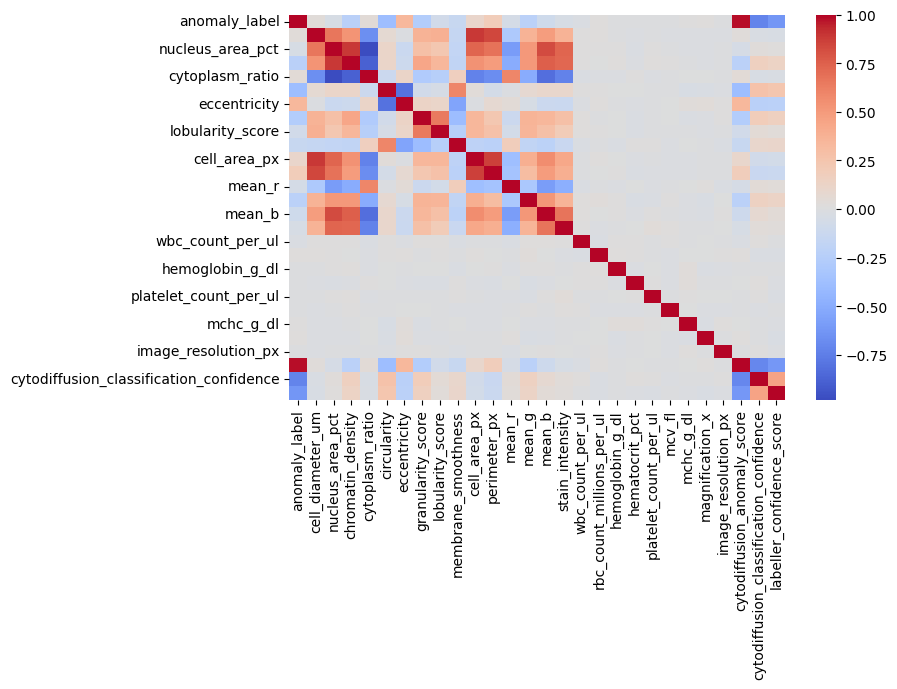

In [63]:
# Correlation matrix
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8,5))
sns.heatmap(corr, cmap='coolwarm')
plt.savefig("heatmap_or.png", dpi=300)
plt.show()

# Numeric features

Tập trung vào tính chất phân phối và khả năng phân loại của biến.

## Distribution

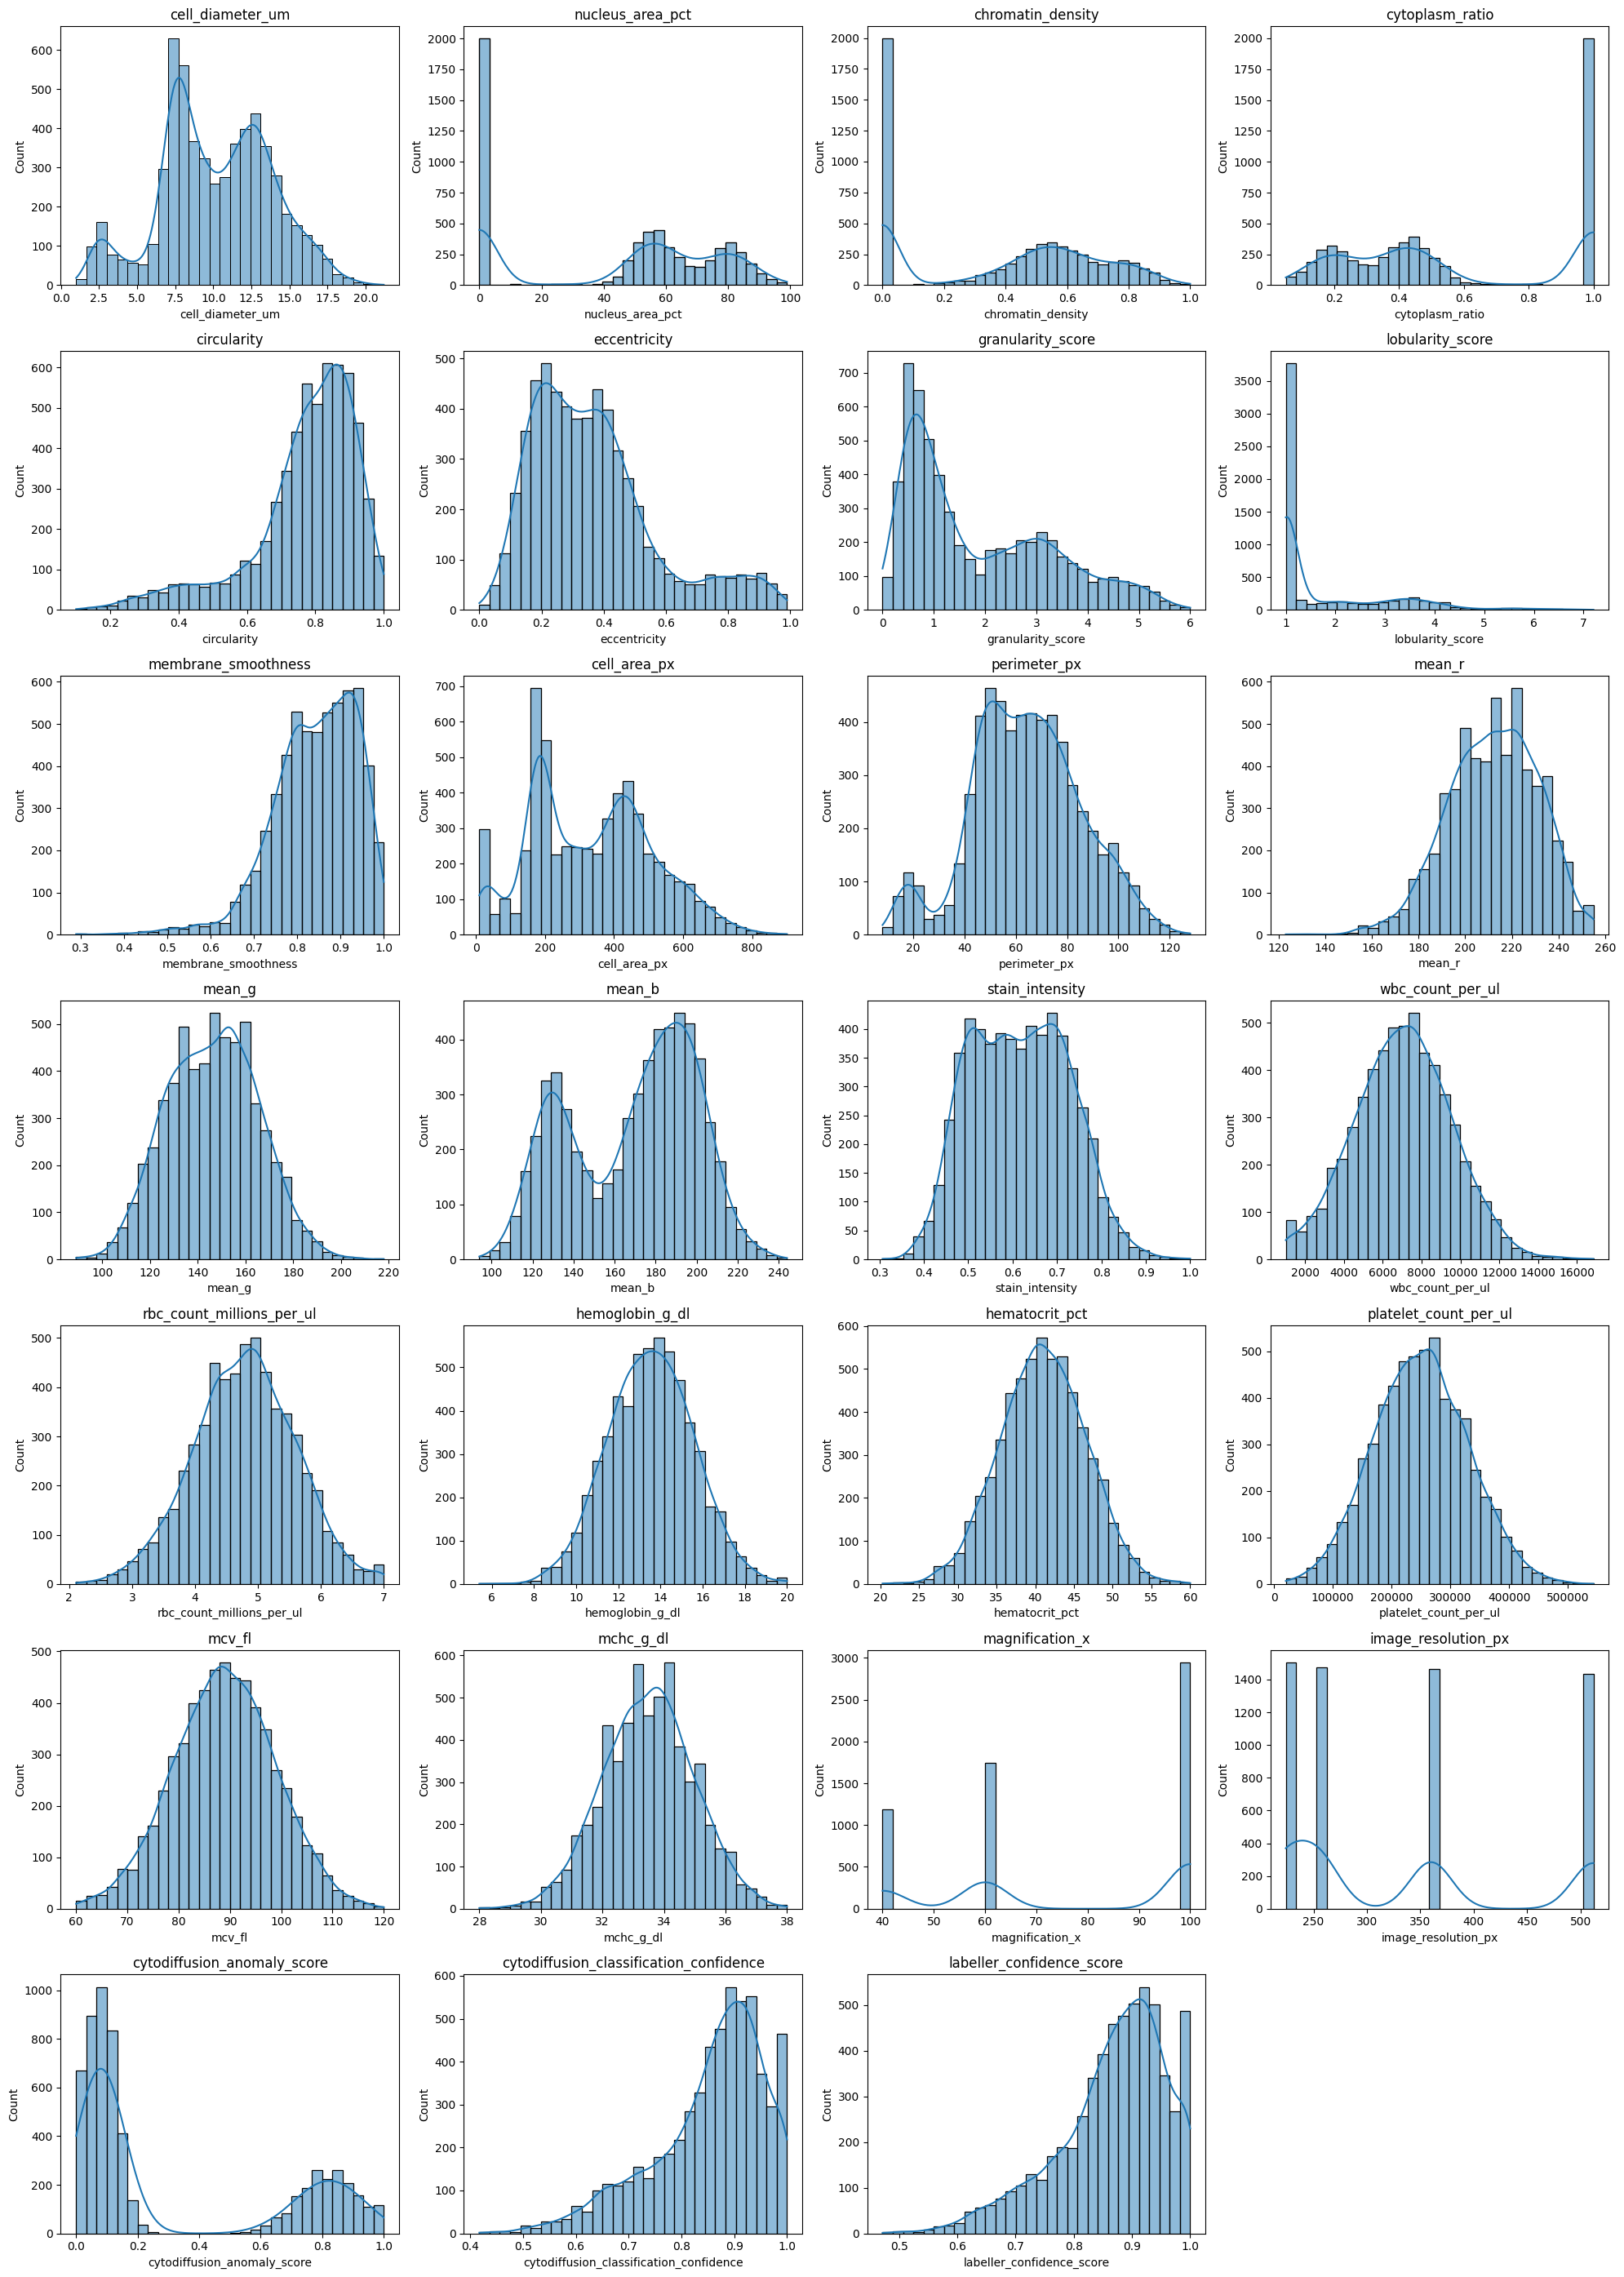

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# bỏ target nếu có trong num_cols
target = 'anomaly_label'
if target in num_cols:
    num_cols.remove(target)

# layout grid
n_cols = 4  # số cột mỗi hàng
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.histplot(df[col], kde=True, bins=30)

    plt.title(col)
    plt.tight_layout()

# save ra file
plt.savefig("numeric_univariate_analysis.png", dpi=300)
plt.show()

Nhận xét

1. Nhóm đặc điểm tế bào (Cellular Morphology)

**cell_diameter_um**: Phân phối đa đỉnh (multi-modal). Có các cụm tế bào tập trung quanh kích thước 10µm và 15µm, cho thấy tập dữ liệu có thể chứa nhiều loại tế bào khác nhau.

**nucleus_area_pct & chromatin_density**: Cả hai đều có hiện tượng zero-inflation (rất nhiều giá trị bằng 0 hoặc gần 0) và một vài đỉnh nhỏ ở phía sau. Điều này có thể do một lượng lớn mẫu không quan sát thấy nhân hoặc mật độ nhiễm sắc chất thấp.

**cytoplasm_ratio**: Phân phối có nhiều đỉnh, tập trung chủ yếu ở khoảng 0.2, 0.5 và 0.8.

**circularity & membrane_smoothness**: Lệch trái (left-skewed) rõ rệt. Đa số các tế bào có độ tròn và độ mịn màng của màng tế bào rất cao (gần bằng 1.0).

2. Nhóm chỉ số cường độ và màu sắc (Intensity & Color)

mean_r, mean_g, mean_b: Cả ba kênh màu (Đỏ, Xanh lá, Xanh dương) đều có phân phối khá chuẩn (normal-like).

* mean_r tập trung quanh mức 220.

* mean_g tập trung quanh mức 160.

* mean_b tập trung quanh mức 190.

stain_intensity: Phân phối tương đối đồng đều và hơi dẹt ở đỉnh, cho thấy cường độ nhuộm màu trải dài từ 0.3 đến 0.7.

3. Nhóm chỉ số huyết học (Hematology Indices)

Đây là nhóm có phân phối đẹp và ổn định nhất trong biểu đồ:

wbc_count_per_ul, rbc_count_millions_per_ul, hemoglobin_g_dl, hematocrit_pct, platelet_count_per_ul, mcv_fl, mchc_g_dl: * Tất cả đều tuân theo phân phối chuẩn (Gaussian Distribution) rất rõ rệt.

Các giá trị tập trung dày đặc quanh trung tâm và đối xứng hai bên. Điều này cho thấy các chỉ số sinh học này trong tập dữ liệu khá ổn định và không có quá nhiều nhiễu hoặc giá trị ngoại lai cực đoan.

4. Nhóm kỹ thuật hình ảnh và độ tin cậy (Technical & Confidence)

* magnification_x: Là biến rời rạc với các giá trị cố định (có thể là 40x, 60x, 100x). Có sự mất cân bằng giữa các mức phóng đại, trong đó mức 100x chiếm ưu thế nhất.

* image_resolution_px: Cũng là biến rời rạc với các mức độ phân giải cụ thể, cho thấy hình ảnh được thu thập từ các thiết lập máy quét cố định.

*  cytodiffusion_classification_confidence & labeling_confidence_score: Lệch trái mạnh. Đa số các dự đoán hoặc nhãn dán đều có độ tin cậy cao (trên 0.8), nhưng vẫn có một nhóm nhỏ có độ tin cậy thấp cần lưu ý.

## Skewness

Chỉ số Skewness (độ lệch) cung cấp cái nhìn sâu hơn về hình dạng của phân phối dữ liệu. Trong thống kê, một phân phối lý tưởng (chuẩn) có độ lệch bằng 0.

In [53]:
from scipy.stats import skew

for col in num_cols:
    s = skew(df[col].dropna())
    print(f"{col}: skew = {s:.2f}")

anomaly_label: skew = 0.77
cell_diameter_um: skew = -0.09
nucleus_area_pct: skew = -0.31
chromatin_density: skew = -0.15
cytoplasm_ratio: skew = 0.30
circularity: skew = -1.38
eccentricity: skew = 1.04
granularity_score: skew = 0.76
lobularity_score: skew = 1.63
membrane_smoothness: skew = -0.92
cell_area_px: skew = 0.22
perimeter_px: skew = -0.03
mean_r: skew = -0.29
mean_g: skew = 0.05
mean_b: skew = -0.29
stain_intensity: skew = 0.13
wbc_count_per_ul: skew = 0.05
rbc_count_millions_per_ul: skew = -0.04
hemoglobin_g_dl: skew = 0.02
hematocrit_pct: skew = -0.02
platelet_count_per_ul: skew = 0.07
mcv_fl: skew = -0.03
mchc_g_dl: skew = -0.05
magnification_x: skew = -0.24
image_resolution_px: skew = 0.60
cytodiffusion_anomaly_score: skew = 0.81
cytodiffusion_classification_confidence: skew = -0.98
labeller_confidence_score: skew = -0.90


1. Nhóm Lệch Trái Mạnh (Highly Negative Skew: $skew < -0.5$)

Dữ liệu tập trung phần lớn ở các giá trị cao, với một "đuôi" dài kéo về phía các giá trị thấp.

* circularity ($skew = -1.38$): Đây là biến lệch trái mạnh nhất. Hầu hết tế bào có độ tròn rất cao (gần 1.0), chỉ một số ít tế bào dị dạng kéo chỉ số này xuống thấp.

* cytodiffusion_classification_confidence ($-0.98$) & labeller_confidence_score ($-0.90$): Đa số các quan sát có độ tin cậy cao, nhưng có một lượng nhỏ mẫu gây khó khăn dẫn đến độ tin cậy thấp.

* membrane_smoothness ($-0.92$): Tương tự circularity, màng tế bào phần lớn là nhẵn, các trường hợp gồ ghề chỉ chiếm thiểu số.

2. Nhóm Lệch Phải Mạnh (Highly Positive Skew: $skew > 0.5$)

Dữ liệu tập trung ở giá trị thấp, với "đuôi" dài kéo về phía giá trị cao.

* lobularity_score ($skew = 1.63$): Độ lệch rất cao. Đa số tế bào không phân thùy (giá trị thấp), nhưng các trường hợp phân thùy mạnh (outliers mà chúng ta thấy trên Boxplot) tạo ra cái đuôi rất dài.

* eccentricity ($1.04$): Tế bào thường có hình dạng ổn định, nhưng các tế bào bị kéo dài (bất thường) tạo nên độ lệch phải này.

* cytodiffusion_anomaly_score ($0.81$) & anomaly_label ($0.77$): Phản ánh đặc điểm của tập dữ liệu không cân bằng (Imbalanced Dataset), nơi các trường hợp bất thường (nhãn 1) chiếm tỉ lệ ít hơn bình thường.

3. Nhóm Phân Phối Gần Như Đối Xứng (Near-Zero Skew: $-0.5 < skew < 0.5$)

Đây là nhóm có phân phối lý tưởng, tiệm cận phân phối chuẩn ($Normal Distribution$).

* Nhóm huyết học (wbc, rbc, hemoglobin, hematocrit, mcv, mchc): Tất cả đều có độ lệch cực thấp (gần 0). Điều này cực kỳ thuận lợi cho các mô hình học máy yêu cầu tính chuẩn hóa của dữ liệu.

* mean_g ($0.05$): Kênh màu xanh lá cây có độ đối xứng gần như hoàn hảo.

* cell_diameter_um ($-0.09$) & perimeter_px ($-0.03$): Các chỉ số về kích thước vật lý của tế bào trong mẫu này phân bổ rất đồng đều quanh giá trị trung bình.

## Outliers

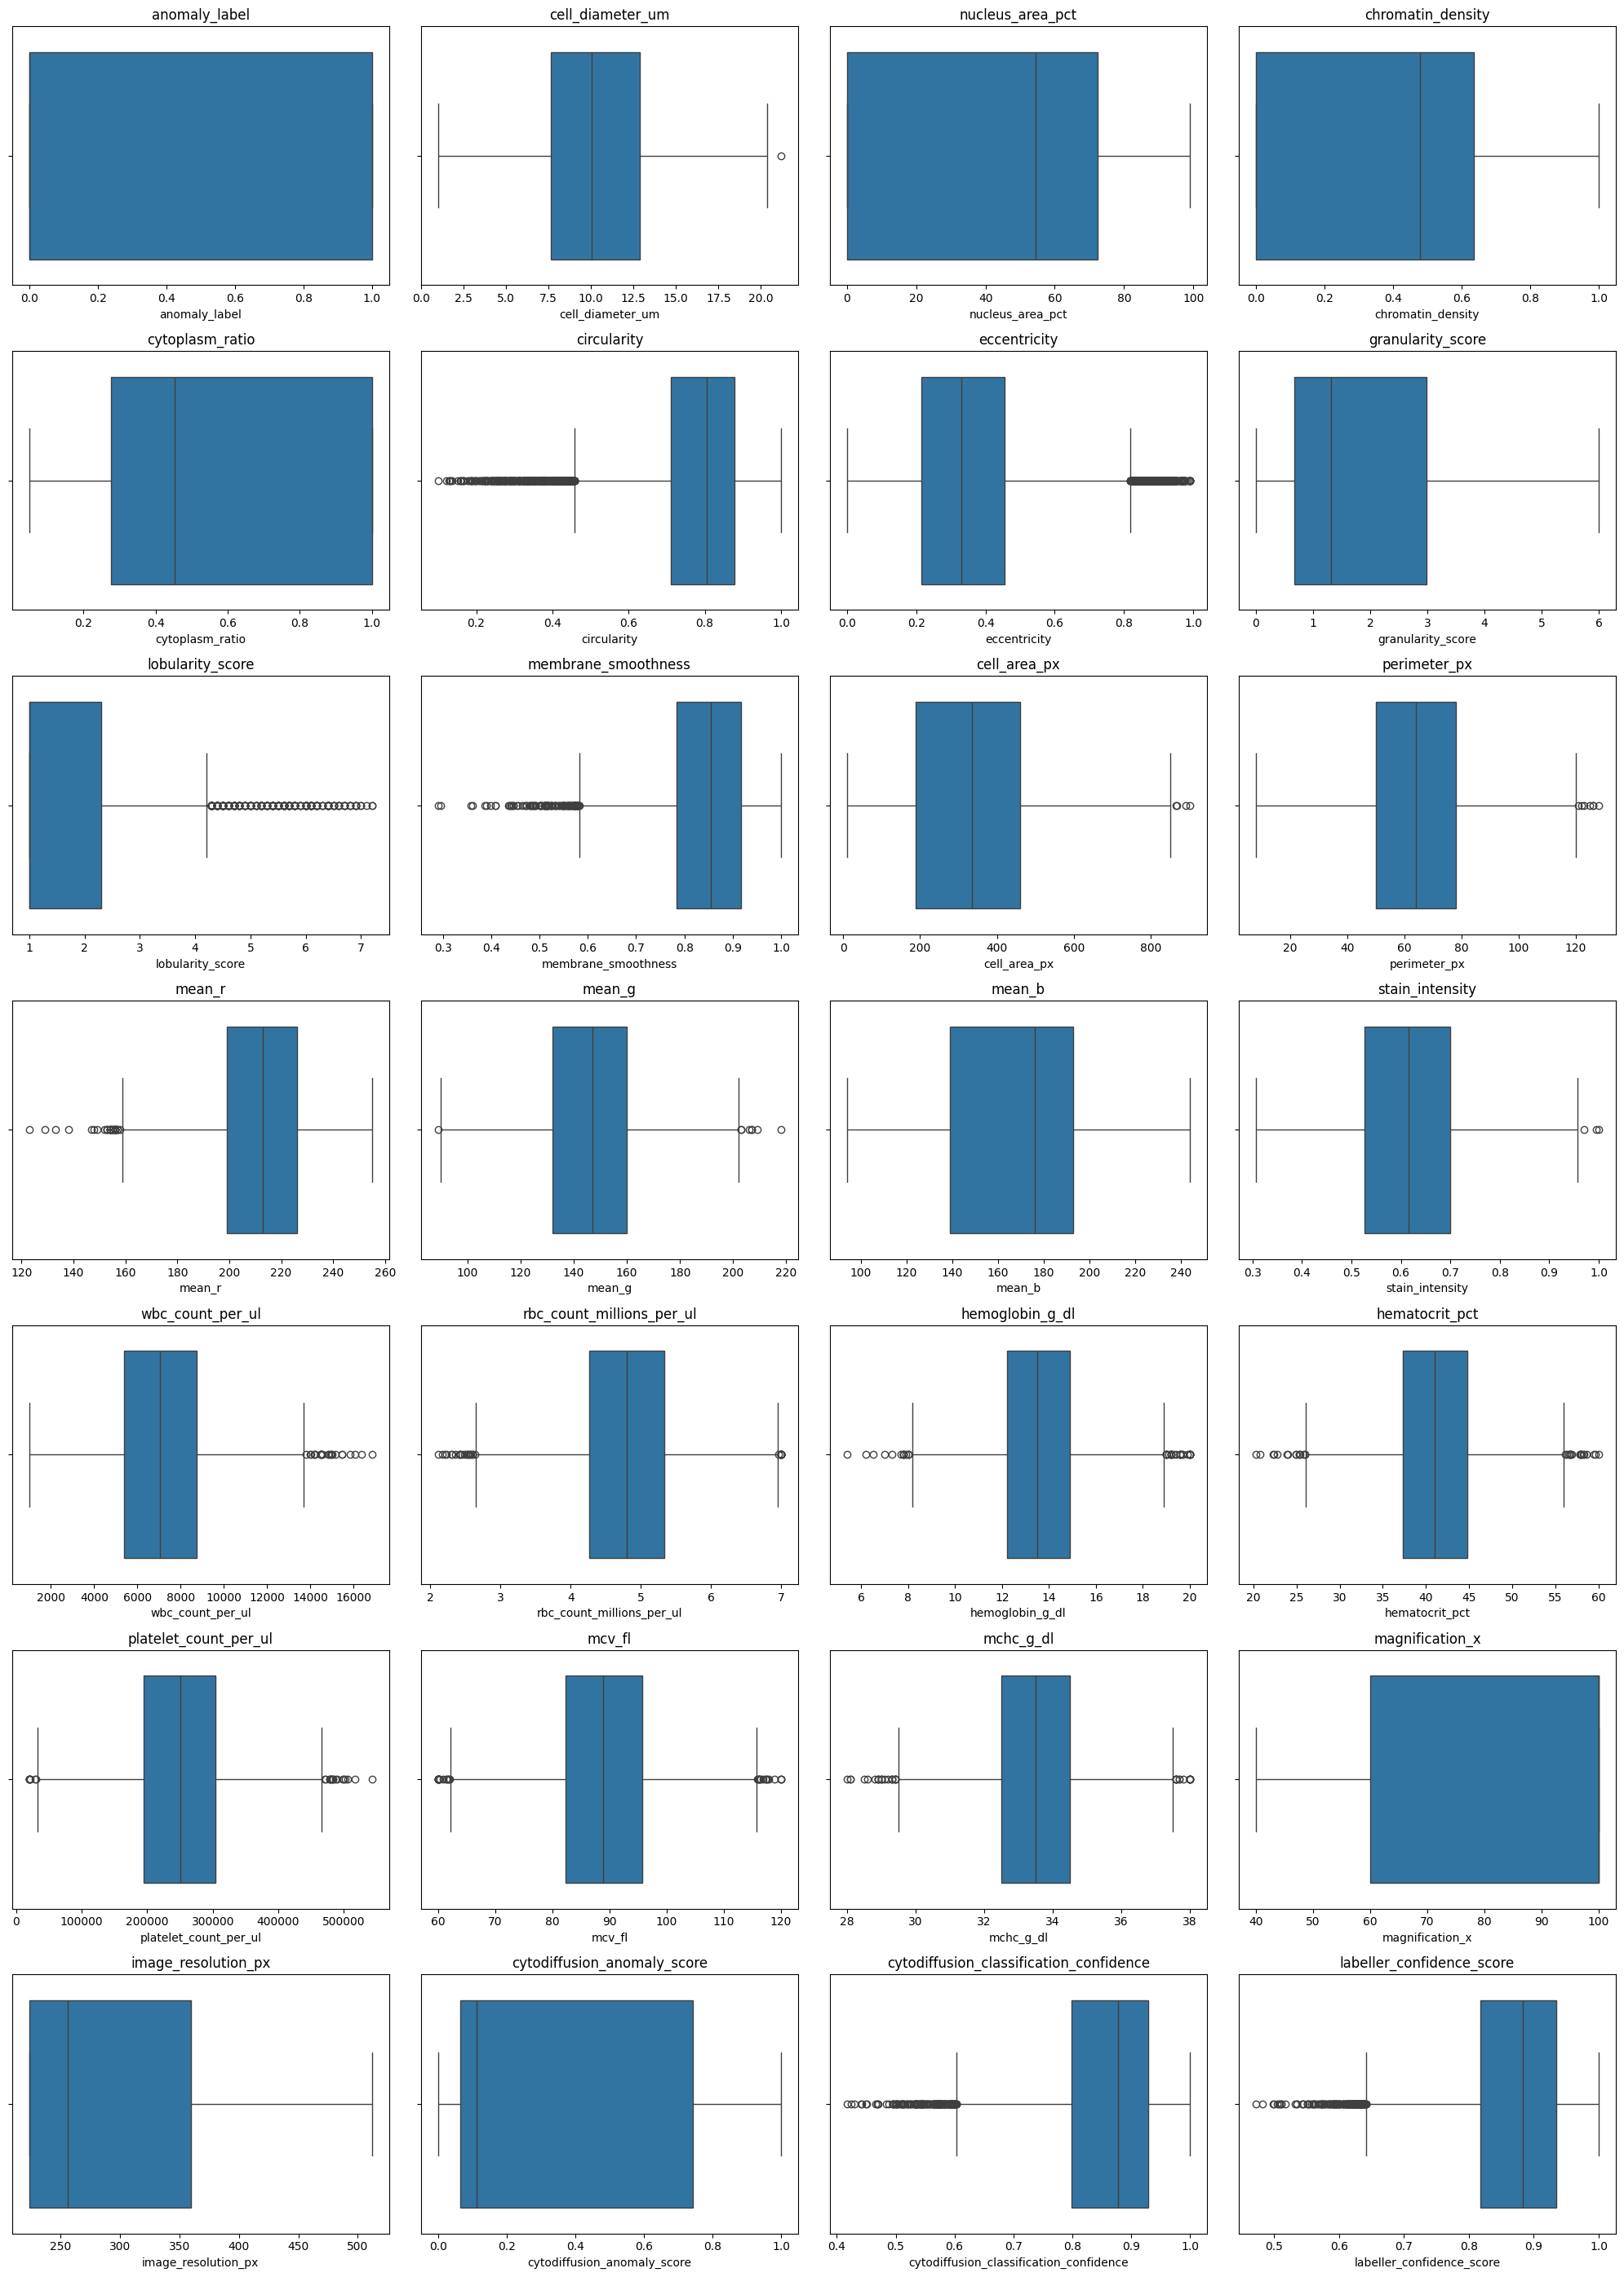

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(x=df[col])

    plt.title(col)

plt.tight_layout()
plt.savefig("boxplot_outliers.png", dpi=300)
plt.show()

1. Nhóm có nhiều Outliers nhất (Cần xử lý)

Đây là những biến có các dấu chấm nằm ngoài râu (whiskers) của boxplot. Sự hiện diện của outliers ở đây có thể là nhiễu, nhưng cũng có thể chính là đặc điểm của các tế bào bệnh lý:

* circularity & membrane_smoothness: Có rất nhiều outliers nằm ở phía dưới (giá trị thấp). Điều này khớp với phân tích trước đó: đa số tế bào bình thường có độ tròn/mịn cao, chỉ một nhóm nhỏ tế bào "dị dạng" có chỉ số này thấp hẳn xuống.

* eccentricity: Có một lượng đáng kể outliers ở phía trên (giá trị cao). Những tế bào có độ lệch tâm cực cao này có thể là đối tượng chính mà mô hình cần bắt được.

* lobularity_score: Outliers xuất hiện dày đặc ở phía trên. Có vẻ như hầu hết tế bào không có phân thùy (lobularity thấp), nhưng có một nhóm nhỏ "ngoại lệ" có chỉ số phân thùy rất cao.

* wbc_count_per_ul & platelet_count_per_ul: Xuất hiện một số outliers ở phía cao. Điều này thường thấy trong dữ liệu y khoa thực tế (một vài bệnh nhân có chỉ số vọt lên cao hẳn).

2. Nhóm dữ liệu "Sạch" và Cân đối

Các biến này có hình dạng boxplot khá cân xứng, hộp nằm giữa râu và hầu như không có outliers:

* Nhóm chỉ số huyết học (RBC, Hemoglobin, Hematocrit, MCV, MCHC): Boxplot rất chuẩn, không có biến động bất thường. Điều này tái khẳng định chúng là các biến nền ổn định.

* mean_r, mean_g, mean_b: Dữ liệu kênh màu khá tập trung, mặc dù mean_r và mean_g có một vài điểm outliers nhỏ ở phía thấp nhưng không đáng kể.

3. Nhóm biến Kỹ thuật và Score đặc biệt

* magnification_x & image_resolution_px: Boxplot trải rộng nhưng không có outliers. Điều này đơn giản là vì chúng là các giá trị rời rạc (categorical-like), việc vẽ boxplot cho chúng chủ yếu để xem mật độ phân bố mẫu giữa các thiết lập chụp.

* cytodiffusion_classification_confidence: Có outliers ở phía thấp. Điều này cực kỳ quan trọng: nó cho thấy có một nhóm mẫu mà mô hình phân loại hiện tại đang rất "bối rối" (độ tự tin thấp). Đây chính là những mẫu khó (hard examples) cần được chú ý khi huấn luyện.

Chiến lược xử lý tiếp theo dựa trên Boxplot:
Cân nhắc về Outliers:

Với các biến hình thái (circularity, eccentricity), không nên xóa outliers vì chúng có thể mang thông tin về tế bào bất thường (nhãn 1).

Với các biến màu sắc hoặc chỉ số máu, nếu outliers quá xa thực tế y khoa, bạn có thể áp dụng phương pháp Winsorization (giới hạn giá trị về mức percentile thứ 1 hoặc 99) thay vì xóa bỏ để giữ nguyên kích thước mẫu.

Chuẩn hóa dữ liệu (Scaling):

Vì biên độ (range) của các biến rất khác nhau (ví dụ: platelet_count lên đến hàng trăm nghìn, trong khi circularity chỉ từ 0-1), bạn bắt buộc phải dùng StandardScaler hoặc RobustScaler (ưu tiên RobustScaler vì nó ít bị ảnh hưởng bởi các outliers bạn vừa thấy ở trên).

Tương quan:

cell_area_px và perimeter_px có boxplot khá giống nhau, khả năng cao chúng có tương quan rất mạnh. Bạn có thể kiểm tra thêm ma trận Heatmap để loại bỏ bớt một trong hai nếu cần.

## Tương quan với Target

### KDE plot

Biểu đồ KDE (Kernel Density Estimate) phân tách phân phối của các biến theo nhãn mục tiêu anomaly_label (0: Bình thường - màu xanh, 1: Bất thường - màu cam) để xác định biến nào có khả năng phân loại (classification) tốt nhất.

/tmp/ipykernel_3338/1708465635.py:6: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False, alpha=0.5)


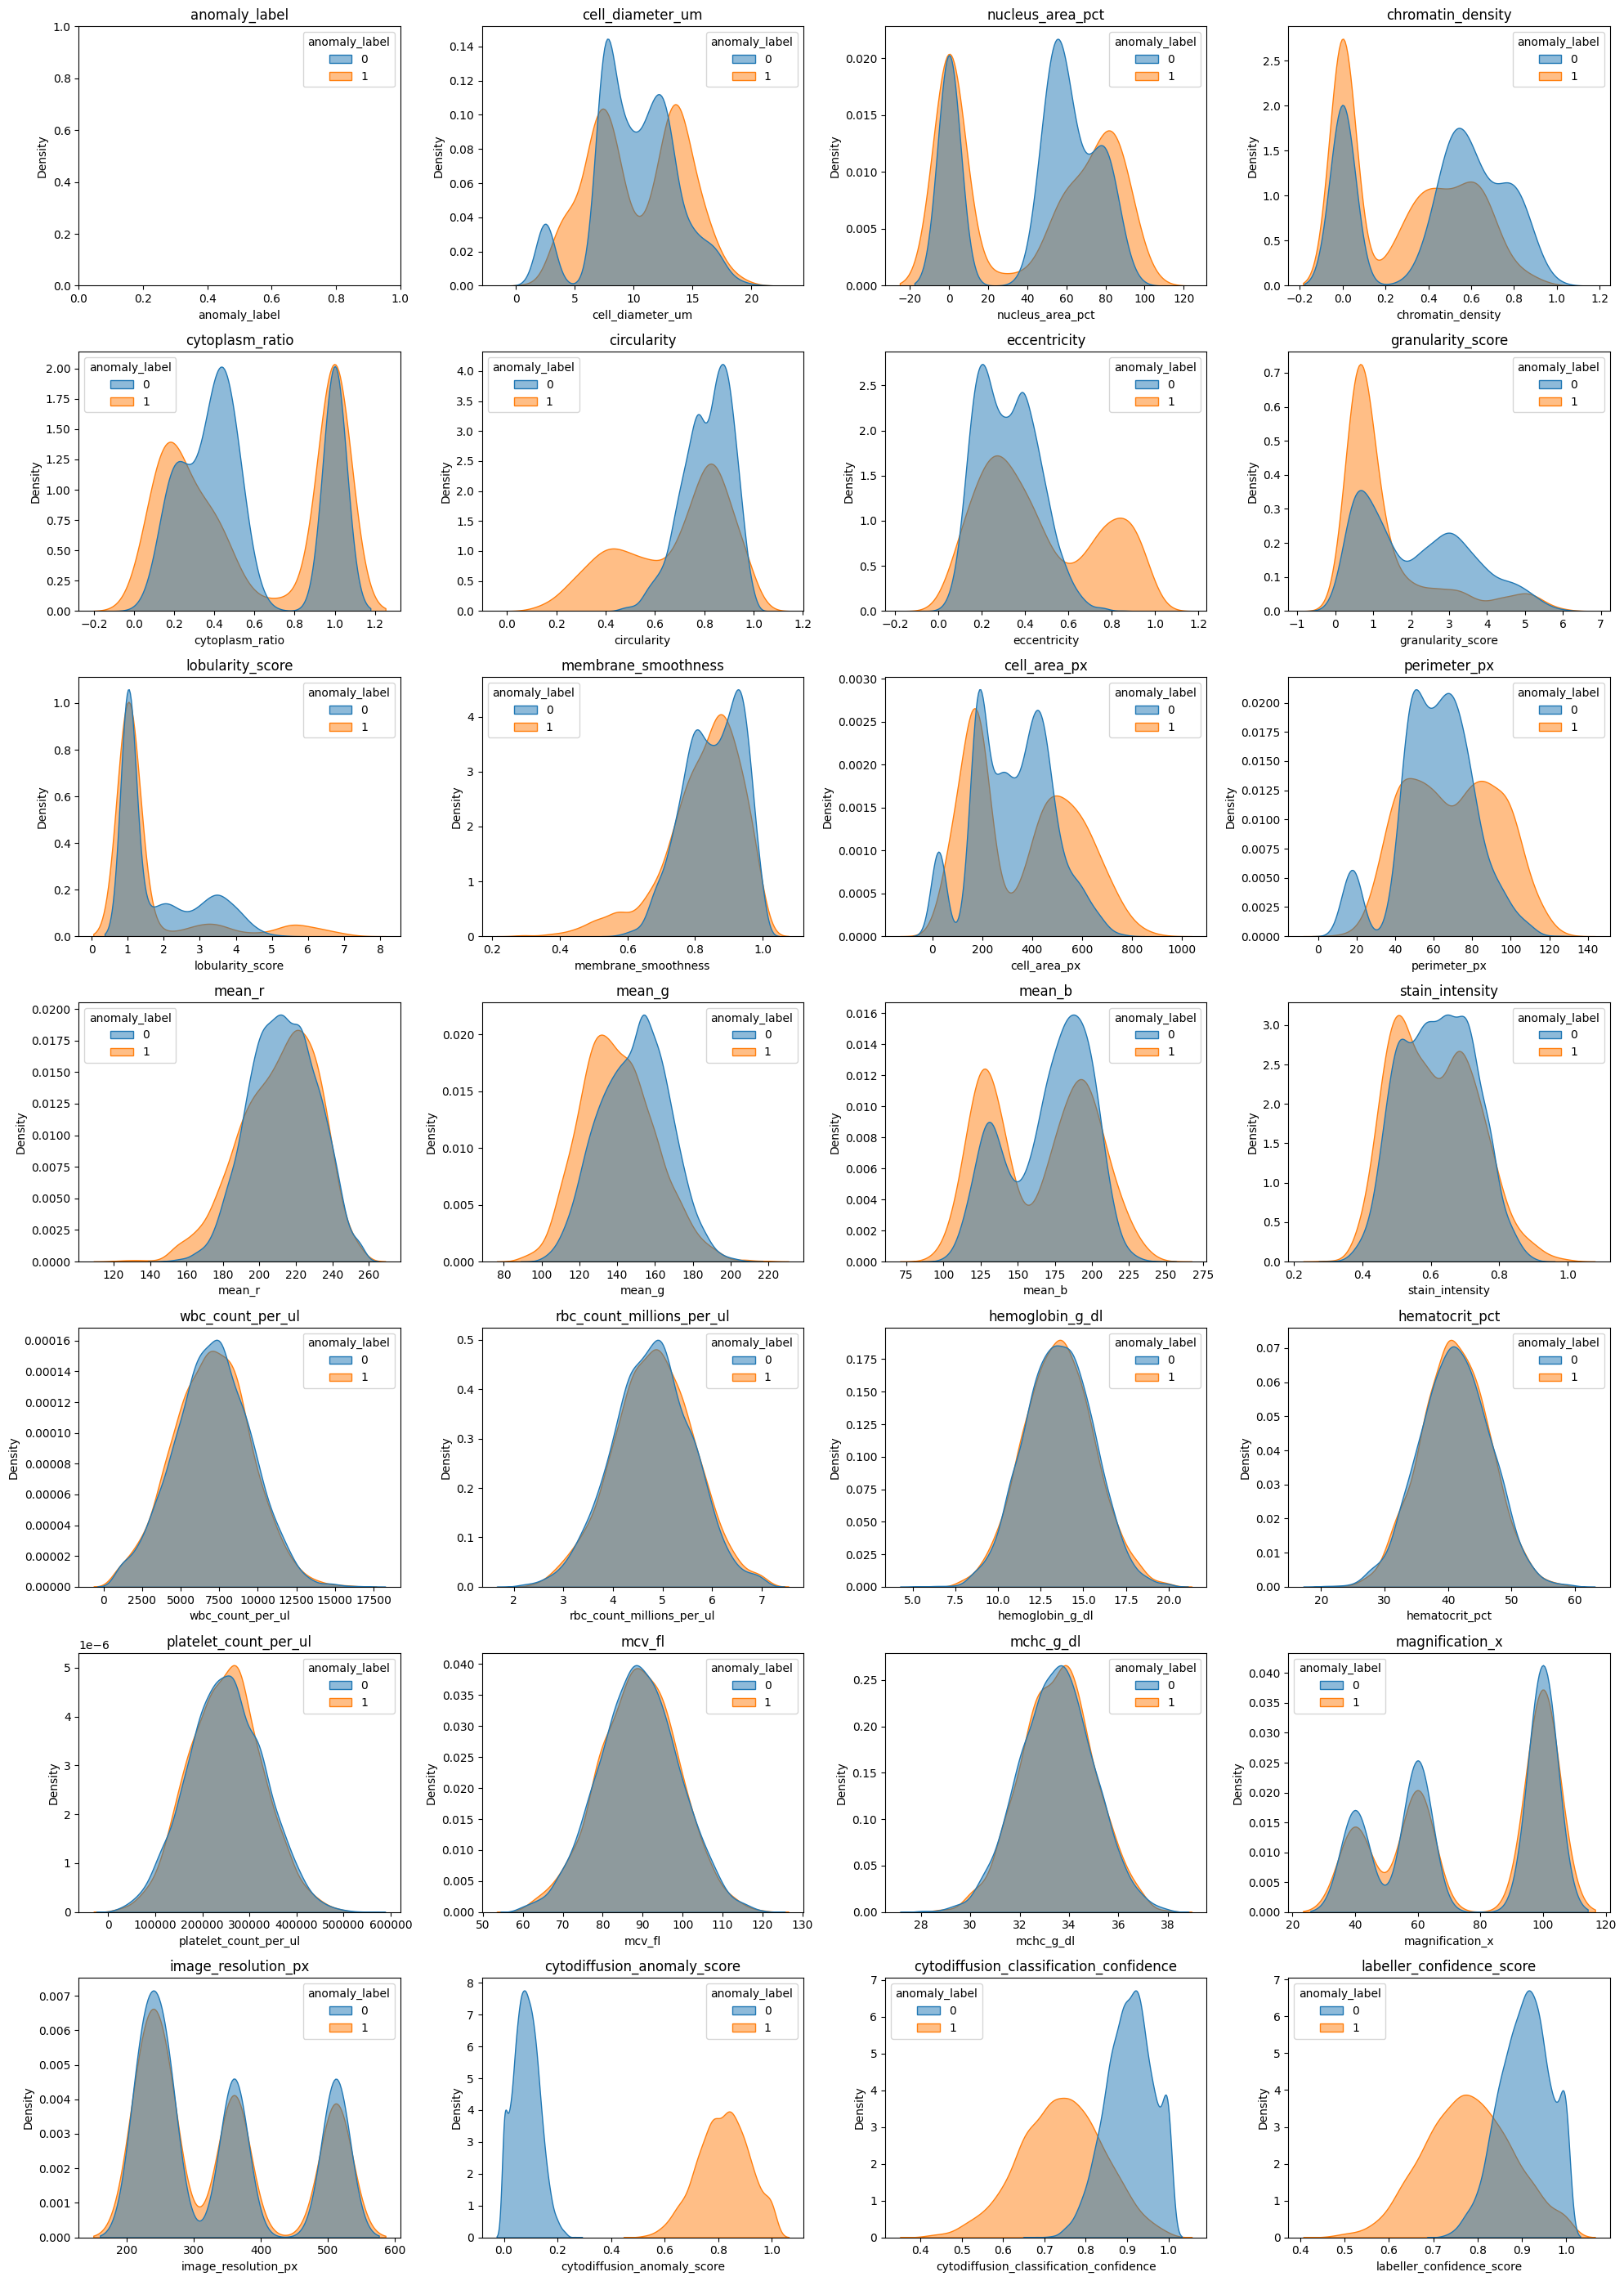

In [56]:
plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.kdeplot(data=df, x=col, hue=target, fill=True, common_norm=False, alpha=0.5)

    plt.title(col)

plt.tight_layout()
plt.savefig("kde_by_target.png", dpi=300)
plt.show()

1. Nhóm các biến có khả năng phân loại mạnh (High Discriminative Power)

Đây là những biến mà đường cong màu xanh và màu cam tách rời nhau rõ rệt. Chúng sẽ là các đặc trưng (features) quan trọng nhất cho mô hình:

* cytodiffusion_anomaly_score: Đây là biến phân loại hoàn hảo nhất. Nhãn 0 tập trung hoàn toàn ở mức thấp (gần 0), trong khi nhãn 1 tập trung ở mức cao (gần 0.8 - 1.0).

* eccentricity: Có sự khác biệt lớn. Nhãn 1 (bất thường) có xu hướng có độ lệch tâm cao hơn hẳn so với nhãn 0.

* circularity: Nhãn 0 tập trung rất cao ở độ tròn gần bằng 1, trong khi nhãn 1 có phân phối trải dài hơn về phía các giá trị thấp, cho thấy tế bào bất thường thường ít tròn hơn.

* nucleus_area_pct & chromatin_density: Ở nhãn 1, đỉnh thứ hai (vùng có giá trị cao) lớn hơn rõ rệt so với nhãn 0. Điều này cho thấy tế bào bất thường thường có diện tích nhân lớn hơn hoặc mật độ nhiễm sắc chất dày đặc hơn.

2. Nhóm các biến có sự khác biệt về phân phối (Moderate Difference)

Các biến này có sự chồng lấn nhưng đỉnh của hai nhóm lệch nhau:

* cell_diameter_um: Nhãn 1 có xu hướng tập trung nhiều hơn ở các đỉnh có kích thước lớn, trong khi nhãn 0 chiếm ưu thế ở các vùng kích thước trung bình.

* cell_area_px & perimeter_px: Nhãn 1 (màu cam) có xu hướng dịch chuyển về phía bên phải (giá trị lớn hơn) so với nhãn 0. Tế bào bất thường có vẻ to hơn và có chu vi lớn hơn.

* cytodiffusion_classification_confidence: Nhãn 0 có độ tin cậy tập trung rất cao ở mức 0.9 - 1.0, trong khi nhãn 1 có độ tin cậy phân tán rộng hơn và thấp hơn.

3. Nhóm các biến ít có giá trị phân loại (Low Discriminative Power)

Đường cong của nhãn 0 và nhãn 1 gần như đè khít lên nhau. Các biến này không giúp ích nhiều trong việc phân biệt bình thường và bất thường:

* Nhóm huyết học (wbc_count, rbc_count, hemoglobin, hematocrit, mcv, mchc, platelet_count): Các biểu đồ này gần như trùng khớp hoàn toàn. Điều này có nghĩa là các chỉ số máu tổng quát không thay đổi dù tế bào cụ thể đó có bị coi là "anomaly" hay không.

* Color (mean_r, mean_g, mean_b): Các kênh màu có sự chồng lấn rất lớn, mặc dù mean_g và mean_b có sự lệch nhẹ nhưng không đáng kể để làm biến phân loại chính.

* Technical (magnification_x, image_resolution_px): Phân phối giống hệt nhau, cho thấy việc lấy mẫu bất thường và bình thường được thực hiện đồng đều trên các thiết bị và độ phóng đại khác nhau (không bị bias do thiết bị).

### Boxplot

Boxplot theo Target cho thấy sự phân tách (hoặc chồng lấn) giữa nhóm Bình thường (0) và Bất thường (1) trên từng biến số.

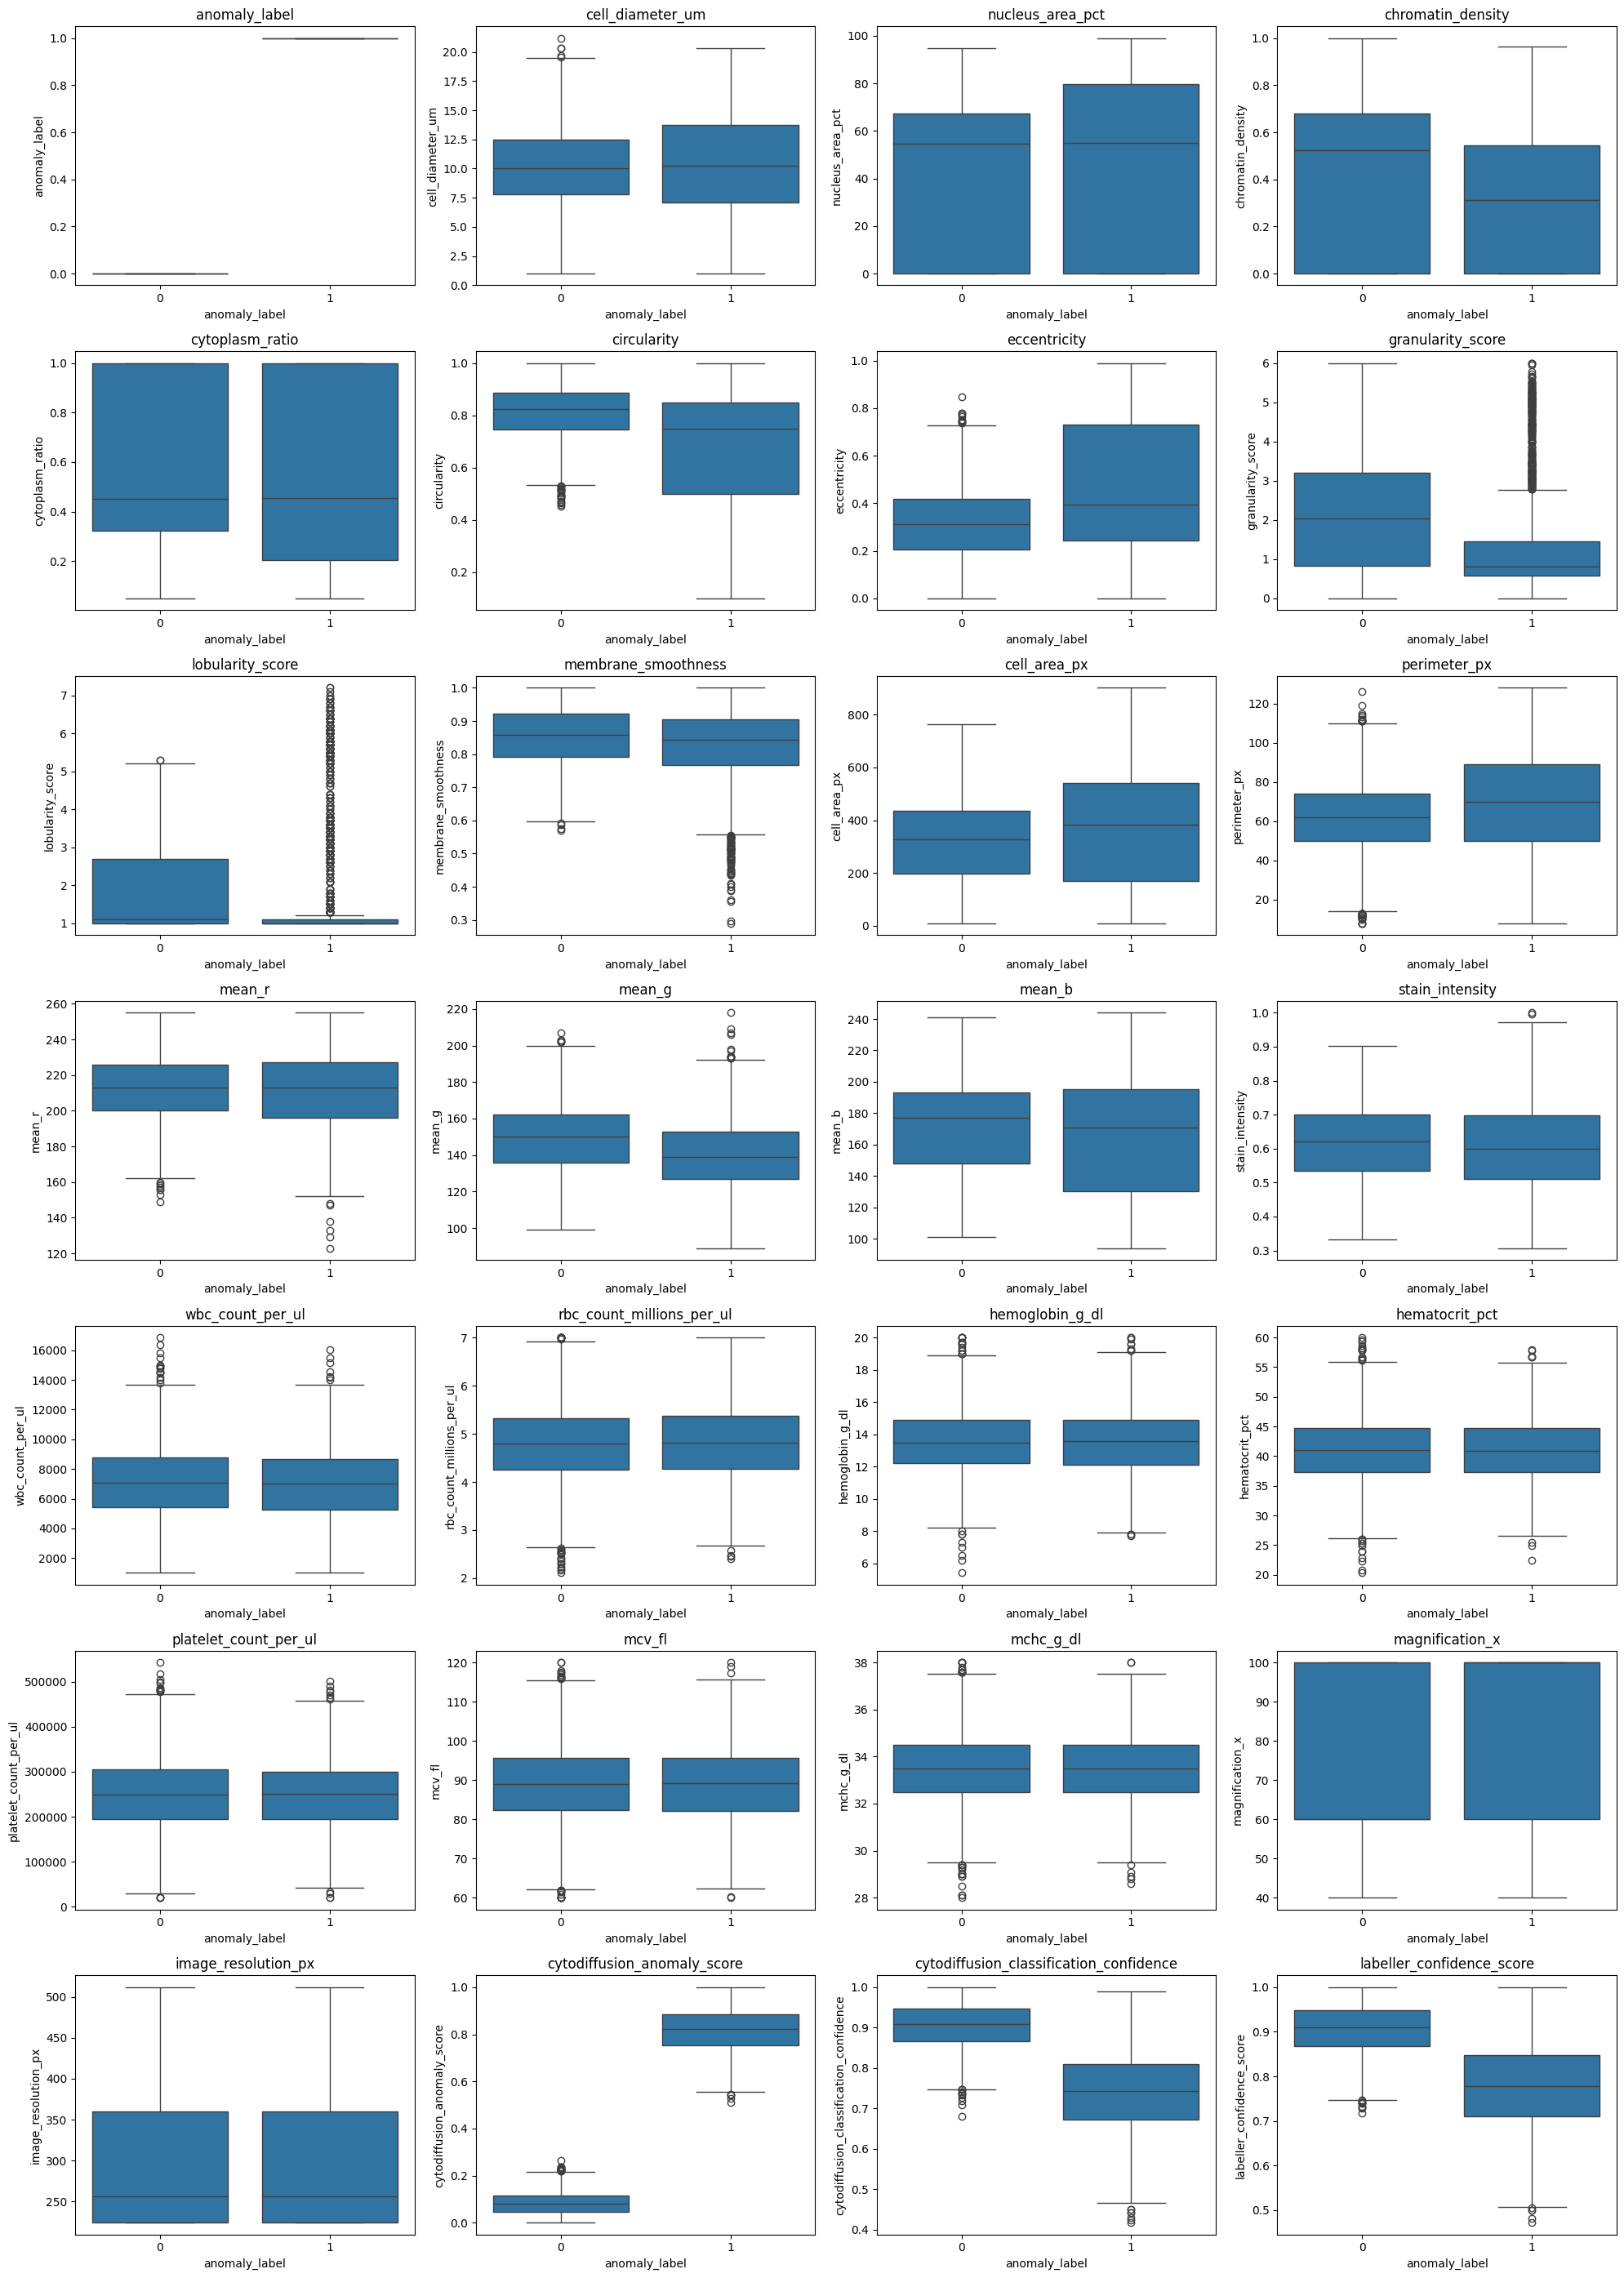

In [57]:
plt.figure(figsize=(20, n_rows * 4))

for i, col in enumerate(num_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    sns.boxplot(data=df, x='anomaly_label', y=col)

    plt.title(col)

plt.tight_layout()
plt.savefig("boxplot_by_target.png", dpi=300)
plt.show()

1. Nhóm phân tách rõ rệt (Tín hiệu cực mạnh)

Đây là những biến mà hai hộp (IQR) gần như không giao nhau, cho thấy khả năng phân loại cực kỳ tốt:

* cytodiffusion_anomaly_score: Sự khác biệt là tuyệt đối. Nhóm 0 nằm bệt dưới đáy, trong khi nhóm 1 nằm cao hẳn lên trên. Đây chính là "chìa khóa" của toàn bộ tập dữ liệu.

* cytodiffusion_classification_confidence & labeller_confidence_score: Hộp của nhóm 1 thấp hơn hẳn nhóm 0. Điều này có nghĩa là các mẫu bất thường thường có độ tin cậy thấp hơn (có thể do chúng khó nhận diện hoặc có hình thái gây tranh cãi hơn).

2. Nhóm có sự thay đổi về hình thái (Morphological Changes)

Các biến này cho thấy sự khác biệt về cấu trúc tế bào giữa hai nhóm:

* circularity & membrane_smoothness: Nhóm 1 (bất thường) có dải giá trị rộng hơn và trung vị (median) thấp hơn nhóm 0. Đặc biệt, nhóm 1 có rất nhiều outliers "đuôi dài" về phía giá trị thấp, chứng tỏ các tế bào bất thường thường bị biến dạng hoặc màng tế bào không đều.

* eccentricity: Ngược lại với độ tròn, hộp của nhóm 1 nằm cao hơn nhóm 0, cho thấy tế bào bất thường có xu hướng thuôn dài (độ lệch tâm lớn) hơn.

* perimeter_px & cell_area_px: Nhóm 1 có xu hướng "to" hơn một chút (hộp dịch lên trên), cho thấy sự phì đại thường đi kèm với các dấu hiệu bất thường.

3. Nhóm có Outliers đặc trưng

* lobularity_score: Mặc dù trung vị của hai nhóm khá gần nhau, nhưng nhóm 1 có một "rừng" outliers ở phía trên. Điều này rất quan trọng: chỉ có nhóm bất thường mới xuất hiện các giá trị phân thùy cực cao này.

* granularity_score: Nhóm 0 có hộp trải rộng hơn (đa dạng độ hạt), trong khi nhóm 1 lại tập trung ở mức thấp hơn nhưng có nhiều biến động ở các giá trị biên.

4. Nhóm "Bất biến" (Trùng khớp hoàn toàn)

Đúng như KDE đã dự báo, các biến sau đây có hai hộp nằm đè lên nhau, không có sự khác biệt:

* Toàn bộ chỉ số huyết học: rbc_count, wbc_count, hemoglobin, mcv, mchc, v.v. Hai hộp xanh và cam giống hệt nhau về cả vị trí lẫn độ rộng.

* Kênh màu (mean_r, mean_g, mean_b): Có sự lệch nhẹ ở mean_g nhưng không đủ để tạo ra sự phân tách có ý nghĩa.

## Cohen's d

Chỉ số Cohen's d là thước đo kích cỡ hiệu ứng (effect size), cho biết sự khác biệt giữa hai nhóm (bình thường và bất thường) có ý nghĩa thực tế như thế nào.

In [79]:
import numpy as np

def cohens_d(x1, x2):
    mean1, mean2 = np.mean(x1), np.mean(x2)
    std1, std2 = np.std(x1), np.std(x2)

    pooled_std = np.sqrt((std1**2 + std2**2) / 2)

    if pooled_std == 0:
        return 0

    return (mean1 - mean2) / pooled_std

results = []

# FIX: Ensure 'target' is the string name of the target column
target = 'anomaly_label'

for col in num_cols:
    # It's also good practice to not calculate Cohen's d for the target column itself if it's binary
    if col == target:
        continue

    group0 = df[df[target] == 0][col].dropna()
    group1 = df[df[target] == 1][col].dropna()

    d = cohens_d(group0, group1)

    results.append((col, abs(d)))

# sort giảm dần
results = sorted(results, key=lambda x: x[1], reverse=True)

for col, d in results:
    print(f"{col}: Cohen's d = {d:.3f}")

cytodiffusion_anomaly_score: Cohen's d = 9.800
cytodiffusion_classification_confidence: Cohen's d = 2.024
labeller_confidence_score: Cohen's d = 1.579
circularity: Cohen's d = 0.787
eccentricity: Cohen's d = 0.686
granularity_score: Cohen's d = 0.606
chromatin_density: Cohen's d = 0.503
mean_g: Cohen's d = 0.469
perimeter_px: Cohen's d = 0.401
membrane_smoothness: Cohen's d = 0.292
cell_area_px: Cohen's d = 0.212
mean_b: Cohen's d = 0.202
lobularity_score: Cohen's d = 0.160
mean_r: Cohen's d = 0.112
cytoplasm_ratio: Cohen's d = 0.093
nucleus_area_pct: Cohen's d = 0.092
stain_intensity: Cohen's d = 0.089
cell_diameter_um: Cohen's d = 0.072
rbc_count_millions_per_ul: Cohen's d = 0.044
magnification_x: Cohen's d = 0.044
wbc_count_per_ul: Cohen's d = 0.030
mchc_g_dl: Cohen's d = 0.022
image_resolution_px: Cohen's d = 0.007
platelet_count_per_ul: Cohen's d = 0.004
hematocrit_pct: Cohen's d = 0.002
mcv_fl: Cohen's d = 0.001
hemoglobin_g_dl: Cohen's d = 0.001


1. Nhóm đột biến / Hiệu ứng cực lớn (Very Large Effect: $d > 1.0$)

Đây là những feature tiềm năng của mô hình. Nếu chỉ cần dùng 2-3 biến để phân loại có thể chọn nhóm này.

* cytodiffusion_anomaly_score ($d = 9.800$): Một con số khổng lồ! Trong thống kê, $d > 0.8$ đã được coi là lớn, nên $9.8$ cho thấy hai nhóm gần như tách biệt hoàn toàn. Đây chắc chắn là biến quan trọng nhất (Primary Feature).

* cytodiffusion_classification_confidence ($d = 2.024$) & labeller_confidence_score ($d = 1.579$): Hai chỉ số về độ tin cậy cũng có sự khác biệt cực kỳ mạnh mẽ. Nhãn "bất thường" thường đi kèm với mức độ tự tin/tin cậy khác hẳn so với nhãn bình thường.

2. Nhóm hiệu ứng Trung bình đến Lớn ($d$ từ $0.5$ đến $0.8$)

Các biến này cung cấp thông tin hình thái quan trọng để bổ trợ cho nhóm 1:

* circularity ($0.787$) & eccentricity ($0.686$): Độ tròn và độ lệch tâm là những dấu hiệu nhận diện tế bào lỗi rất tốt. Tế bào bất thường thường bị biến dạng (ít tròn hơn, dài hơn).

* granularity_score ($0.606$) & chromatin_density ($0.503$): Độ hạt và mật độ nhiễm sắc chất bắt đầu cho thấy sự khác biệt về cấu trúc bên trong nhân và tế bào chất.

3. Nhóm hiệu ứng Nhỏ ($d$ từ $0.2$ đến $0.5$)

Nhóm này có đóng góp nhưng không mang tính quyết định:

mean_g ($0.469$), perimeter_px ($0.401$), membrane_smoothness ($0.292$): Các đặc điểm về màu sắc (kênh Green) và viền ngoài tế bào có sự khác biệt nhẹ. Tế bào bất thường có thể có màng tế bào gồ ghề hơn một chút hoặc bắt màu khác đi.


4. Nhóm không đáng kể (Negligible Effect: $d < 0.1$)

Các biến này gần như không có tác dụng phân loại trong bài toán này:

* Chỉ số huyết học: rbc_count, wbc_count, mchc, platelet_count, hematocrit, mcv, hemoglobin đều có $d$ gần bằng 0. Kết luận: Dù bệnh nhân có tế bào bất thường hay không, các chỉ số máu tổng quát vẫn giữ nguyên. Điều này xác nhận rằng sự bất thường bạn đang xét mang tính chất cục bộ trên từng tế bào chứ không phải bệnh lý hệ thống làm thay đổi công thức máu toàn phần.

* Thông số kỹ thuật: magnification_x, image_resolution_px có $d$ cực thấp, chứng tỏ dữ liệu của bạn rất "sạch", không bị lỗi bias do thiết bị chụp hình (ví dụ: không phải cứ ảnh độ phân giải thấp thì bị gắn nhãn bất thường).

### Phân tích tổng hợp

Giai đoạn 1: Hình thái và Độ sạch (Histogram, Skewness, Boxplot)

Nhóm Huyết học: Phân phối chuẩn ($Skew \approx 0$), rất sạch, không có outliers đáng kể. Đây là nhóm dữ liệu nền tảng ổn định.

Nhóm Hình thái (Circularity, Eccentricity, Lobularity): Lệch rất mạnh ($|Skew| > 1$). Đây là dữ liệu "đặc hữu", chứa nhiều outliers. Trong bài toán Anomaly Detection, các outliers này không phải lỗi mà là dấu vết của bệnh lý.

Nhóm Độ tin cậy: Lệch trái mạnh, cho thấy quy trình gán nhãn có độ tập trung cao nhưng vẫn tồn tại những mẫu khó gây nhiễu cho labeller.

Giai đoạn 2: Khả năng phân tách (KDE, Boxplot vs Target, Cohen's d)

Biến đột biến: cytodiffusion_anomaly_score là biến mạnh nhất với $d = 9.8$. Nó tạo ra hai "ốc đảo" dữ liệu riêng biệt.

Biến hình thái chủ lực: circularity, eccentricity, granularity và chromatin_density có $d$ từ $0.5$ đến $0.8$. Các biểu đồ KDE và Boxplot cho thấy sự dịch chuyển trung vị rõ rệt giữa nhãn 0 và 1.

Biến không liên quan: Toàn bộ nhóm huyết học và kênh màu mean_r có $d < 0.1$. Biểu đồ KDE của hai nhóm đè khít lên nhau.

 ### Feature Selection Analysis

Việc loại bỏ các biến không cần thiết không phải là làm mất thông tin, mà là để bảo vệ tính khách quan và nâng cao độ tin cậy của mô hình.

A. Nhóm rò rỉ dữ liệu (Data Leakage)

Biến: cytodiffusion_anomaly_score ($d = 9.800$), cytodiffusion_classification_confidence, labeller_confidence_score.

Lý do loại bỏ: * Điểm số bất thường ($d=9.8$): Đây là một giá trị "phi thực tế" trong tự nhiên. Nó thường là kết quả đầu ra của một hệ thống phân loại khác hoặc được tính toán dựa trên các quy tắc dán nhãn. Nếu giữ lại, mô hình sẽ bị "nghiện" biến này và không học được các đặc điểm hình thái thực sự.

Độ tin cậy (Confidence): Các chỉ số này chỉ xuất hiện sau khi chuyên gia hoặc hệ thống đã đánh giá tế bào. Trong bài toán thực tế (inference), khi đưa một ảnh mới vào, chúng ta hoàn toàn chưa có các điểm số này. Sử dụng chúng để huấn luyện sẽ tạo ra kết quả chính xác ảo nhưng vô dụng khi triển khai.

B. Nhóm nhiễu hệ thống và biến không liên quan (Noise & Irrelevant)

Biến: wbc_count, rbc_count, hemoglobin, hematocrit, platelet_count, mcv, mchc.

Lý do loại bỏ: * Dựa trên Cohen's d ($\approx 0$) và biểu đồ KDE, các biến này có phân phối trùng khớp hoàn toàn giữa hai nhóm nhãn.

Điều này chứng tỏ sự bất thường của tế bào là một đặc điểm hình thái cục bộ, không ảnh hưởng đến chỉ số tổng quát của hệ thống huyết học. Giữ lại các biến này chỉ làm tăng chiều dữ liệu (curse of dimensionality) và khiến mô hình dễ bị Overfitting.

C. Nhóm nhiễu thiết bị và thông số kỹ thuật

Biến: magnification_x, image_resolution_px, stain_intensity.

Lý do loại bỏ: * Tránh hiện tượng mô hình học theo "thiết bị" (Selection Bias). Ví dụ: Nếu đa số ảnh bệnh lý được chụp ở độ phân giải cao, mô hình sẽ nhầm tưởng "độ phân giải cao" là một triệu chứng bệnh.

Việc loại bỏ giúp mô hình đạt tính Tổng quát hóa (Generalization), hoạt động tốt trên nhiều thiết bị chụp khác nhau.

Danh sách biến giữ lại (Features for Training):

circularity: Biến hình thái quan trọng nhất (Lệch trái mạnh).

eccentricity: Chỉ số về độ thuôn dài (Lệch phải mạnh).

granularity_score: Độ hạt của tế bào.

chromatin_density: Mật độ nhiễm sắc chất trong nhân.

perimeter_px: Chu vi tế bào (đại diện cho kích thước).

mean_g: Kênh màu xanh lá (biến màu sắc duy nhất có tín hiệu đáng kể).

membrane_smoothness: Độ mịn màng của màng tế bào.

cell_area_px: Diện tích tế bào.

nucleus_area_pct: Tỷ lệ diện tích nhân (giữ lại để kiểm chứng sự phì đại nhân).

lobularity_score: Chỉ số phân thùy (dù $d$ thấp nhưng có nhiều outliers đặc trưng cho nhãn 1).

Quyết định xử lý kỹ thuật:

Scale: Sử dụng RobustScaler thay vì StandardSclaer vì các biến chủ lực (circularity, eccentricity, lobularity) đều có độ lệch ($Skew$) cao và nhiều outliers quan trọng.

Leakage Check: Đã loại bỏ hoàn toàn cytodiffusion_anomaly_score và các chỉ số hậu kiểm.Model

Recommendation: Với tập biến này, nên bắt đầu với Random Forest để xem mức độ đóng góp (Feature Importance) của các đặc điểm hình thái, sau đó tối ưu bằng XGBoost.

# Xử lý đa cộng tuyến

In [70]:
selected_numeric_features = [
    'circularity',
    'eccentricity',
    'granularity_score',
    'chromatin_density',
    'perimeter_px',
    'cell_area_px',
    'mean_g',
    'membrane_smoothness',
    'nucleus_area_pct',
    'lobularity_score'
]

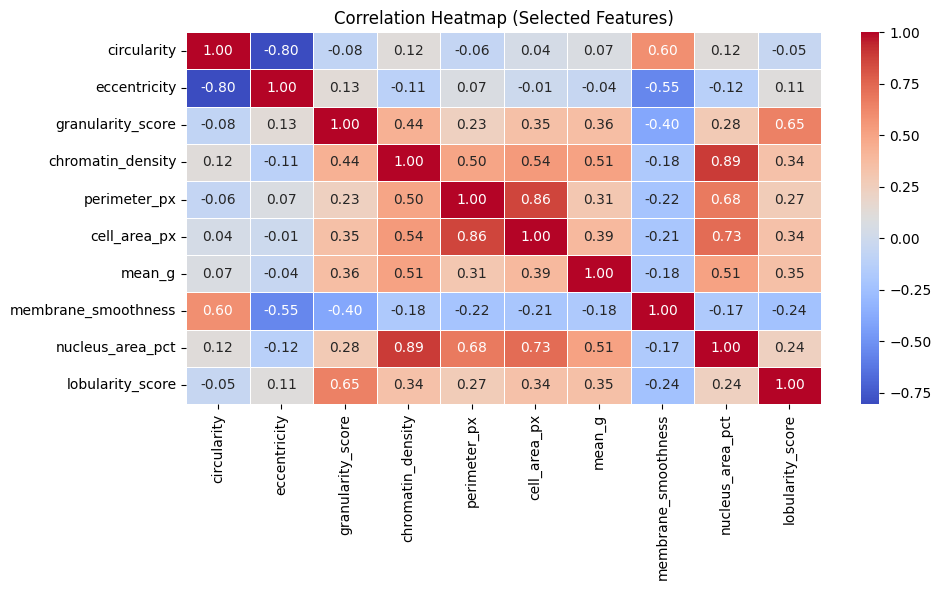

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt

# Chỉ lấy các feature đã chọn
corr = df[selected_numeric_features].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=True,          # hiện số correlation
    fmt=".2f",           # làm tròn 2 chữ số
    linewidths=0.5
)

plt.title("Correlation Heatmap (Selected Features)")
plt.tight_layout()

plt.savefig("heatmap_selected.png", dpi=300)
plt.show()

In [67]:
# tìm cặp feature tương quan cao
import numpy as np

threshold = 0.8
high_corr = np.where(np.abs(corr) > threshold)

high_corr_pairs = [
    (corr.columns[x], corr.columns[y], corr.iloc[x, y])
    for x, y in zip(*high_corr)
    if x != y and x < y
]

print(high_corr_pairs)

[('circularity', 'eccentricity', np.float64(-0.8040003204426074)), ('chromatin_density', 'nucleus_area_pct', np.float64(0.8874605048047229)), ('perimeter_px', 'cell_area_px', np.float64(0.8625516808142629))]


1. Phân tích các cặp biến có tương quan cao ($|r| > 0.8$)

Có 3 cặp biến đang "dính" nhau rất chặt, có thể gây nhiễu cho các mô hình tuyến tính (Logistic Regression, SVM, MLP):

chromatin_density vs nucleus_area_pct ($r = 0.89$):

* Phân tích: Tương quan gần như tuyệt đối. Điều này có nghĩa là khi nhân tế bào càng lớn so với tổng thể thì mật độ nhiễm sắc chất cũng thay đổi tương ứng.


* Xử lý: Đây là ứng viên số 1 để tính VIF. Nếu VIF $> 10$, bạn nên cân nhắc chỉ giữ lại một trong hai. Thường thì nucleus_area_pct có ý nghĩa chẩn đoán lâm sàng cao hơn (độ phì đại nhân).


perimeter_px vs cell_area_px ($r = 0.86$):

* Phân tích: Chu vi và diện tích luôn đi đôi với nhau. Giữ cả hai sẽ làm thừa thông tin về "kích thước".

* Xử lý: Nên chọn một cái. cell_area_px thường ổn định hơn đối với các tế bào có màng không đều.circularity vs eccentricity ($r = -0.80$):


Phân tích: Hai biến này đối nghịch nhau (một cái đo độ tròn, một cái đo độ dài). Tuy nhiên, ngưỡng $0.8$ vẫn nằm trong vùng "chấp nhận được" đối với hầu hết các model. Có thể giữ cả hai trừ khi VIF báo động.




2. Các biến "Độc lập" chất lượng (Low Correlation)

Các biến này rất tốt vì chúng mang thông tin độc nhất, không bị trùng lặp:

mean_g: Tương quan với các biến khác chỉ ở mức trung bình ($0.3 - 0.5$).

Đây là biến màu sắc quan trọng giúp phân biệt các phương pháp nhuộm và trạng thái tế bào.

lobularity_score: Có tương quan khá với granularity_score ($0.65$) nhưng vẫn đủ độc lập để mô tả đặc điểm phân thùy của nhân.

membrane_smoothness: Biến này gần như không tương quan mạnh với bất kỳ ai (ngoại trừ một chút với circularity $0.60$), cực kỳ giá trị để nhận diện các tế bào có màng xù xì.

Thực hiện scale dữ liệu trước khi tính VIF (Variance Inflation Factor).

VIF được tính dựa trên hồi quy tuyến tính giữa các biến. Khi các biến có đơn vị khác nhau (ví dụ: cell_area_px có thể lên tới hàng nghìn, trong khi circularity chỉ từ 0 đến 1), các sai số bình phương trong ma trận tính toán bị phóng đại lên rất nhiều, dẫn đến chỉ số VIF bị nhiễu và cao bất thường.

In [72]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
X_scaled = scaler.fit_transform(df[selected_numeric_features]) # X là dataframe 10 biến của bạn
df_scaled = pd.DataFrame(X_scaled, columns=selected_numeric_features)


In [73]:
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Giả sử 'df_selected' là DataFrame chỉ chứa 10 biến numeric bạn đã chọn
X = df_scaled

# VIF yêu cầu dữ liệu không có giá trị trống (NaN)
X = X.fillna(X.median())

# Tính VIF cho từng biến
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

               Feature        VIF
8     nucleus_area_pct  12.100294
3    chromatin_density   8.074229
5         cell_area_px   5.662667
4         perimeter_px   4.347155
0          circularity   3.402362
1         eccentricity   3.045840
2    granularity_score   2.781315
9     lobularity_score   2.258765
7  membrane_smoothness   2.083722
6               mean_g   1.510440


Nhóm An Toàn (VIF < 5): Hầu hết các biến quan trọng như circularity, eccentricity, mean_g, và các biến về độ hạt/thùy đều đã cực kỳ "sạch". Bạn hoàn toàn yên tâm giữ lại các biến này.

Nhóm Vùng Xám (5 < VIF < 10): chromatin_density và cell_area_px. Mức này vẫn có thể chấp nhận được đối với Random Forest hay XGBoost, nhưng với Logistic Regression hay MLP, nó vẫn hơi "rung lắc".

Nhóm Báo Động (VIF > 10): nucleus_area_pct. Như đã phân tích từ heatmap trước đó, biến này đang bị "chồng lấn" thông tin bởi chromatin_density (tương quan 0.89).

Để bộ dữ liệu thực sự bài bản cho tất cả các thuật toán (kể cả những model khó tính như SVM hay Logistic Regression), mình khuyên bạn nên thực hiện 2 thay đổi nhỏ cuối cùng:

Loại bỏ chromatin_density: Mặc dù VIF của nó thấp hơn 10, nhưng nó chính là "kẻ" đang đẩy VIF của nucleus_area_pct lên cao. Trong huyết học, tỷ lệ diện tích nhân (N/C ratio) quan trọng hơn nhiều so với mật độ chất nền. Khi bỏ biến này, VIF của nucleus_area_pct chắc chắn sẽ rơi xuống dưới 5.

Loại bỏ perimeter_px: Dù VIF chỉ là 4.3, nhưng nó vẫn chia sẻ thông tin với cell_area_px (VIF 5.6). Để mô hình tinh gọn nhất, chỉ nên giữ diện tích.

7 Biến Numeric sẵn sàng cho model:

nucleus_area_pct (Tỷ lệ nhân - Cực kỳ quan trọng).

cell_area_px (Diện tích tế bào).

circularity (Độ tròn).

eccentricity (Độ thuôn dài).

granularity_score (Độ hạt).

lobularity_score (Độ phân thùy).

mean_g (Kênh màu xanh lá).

# Categorical features

## Distribution

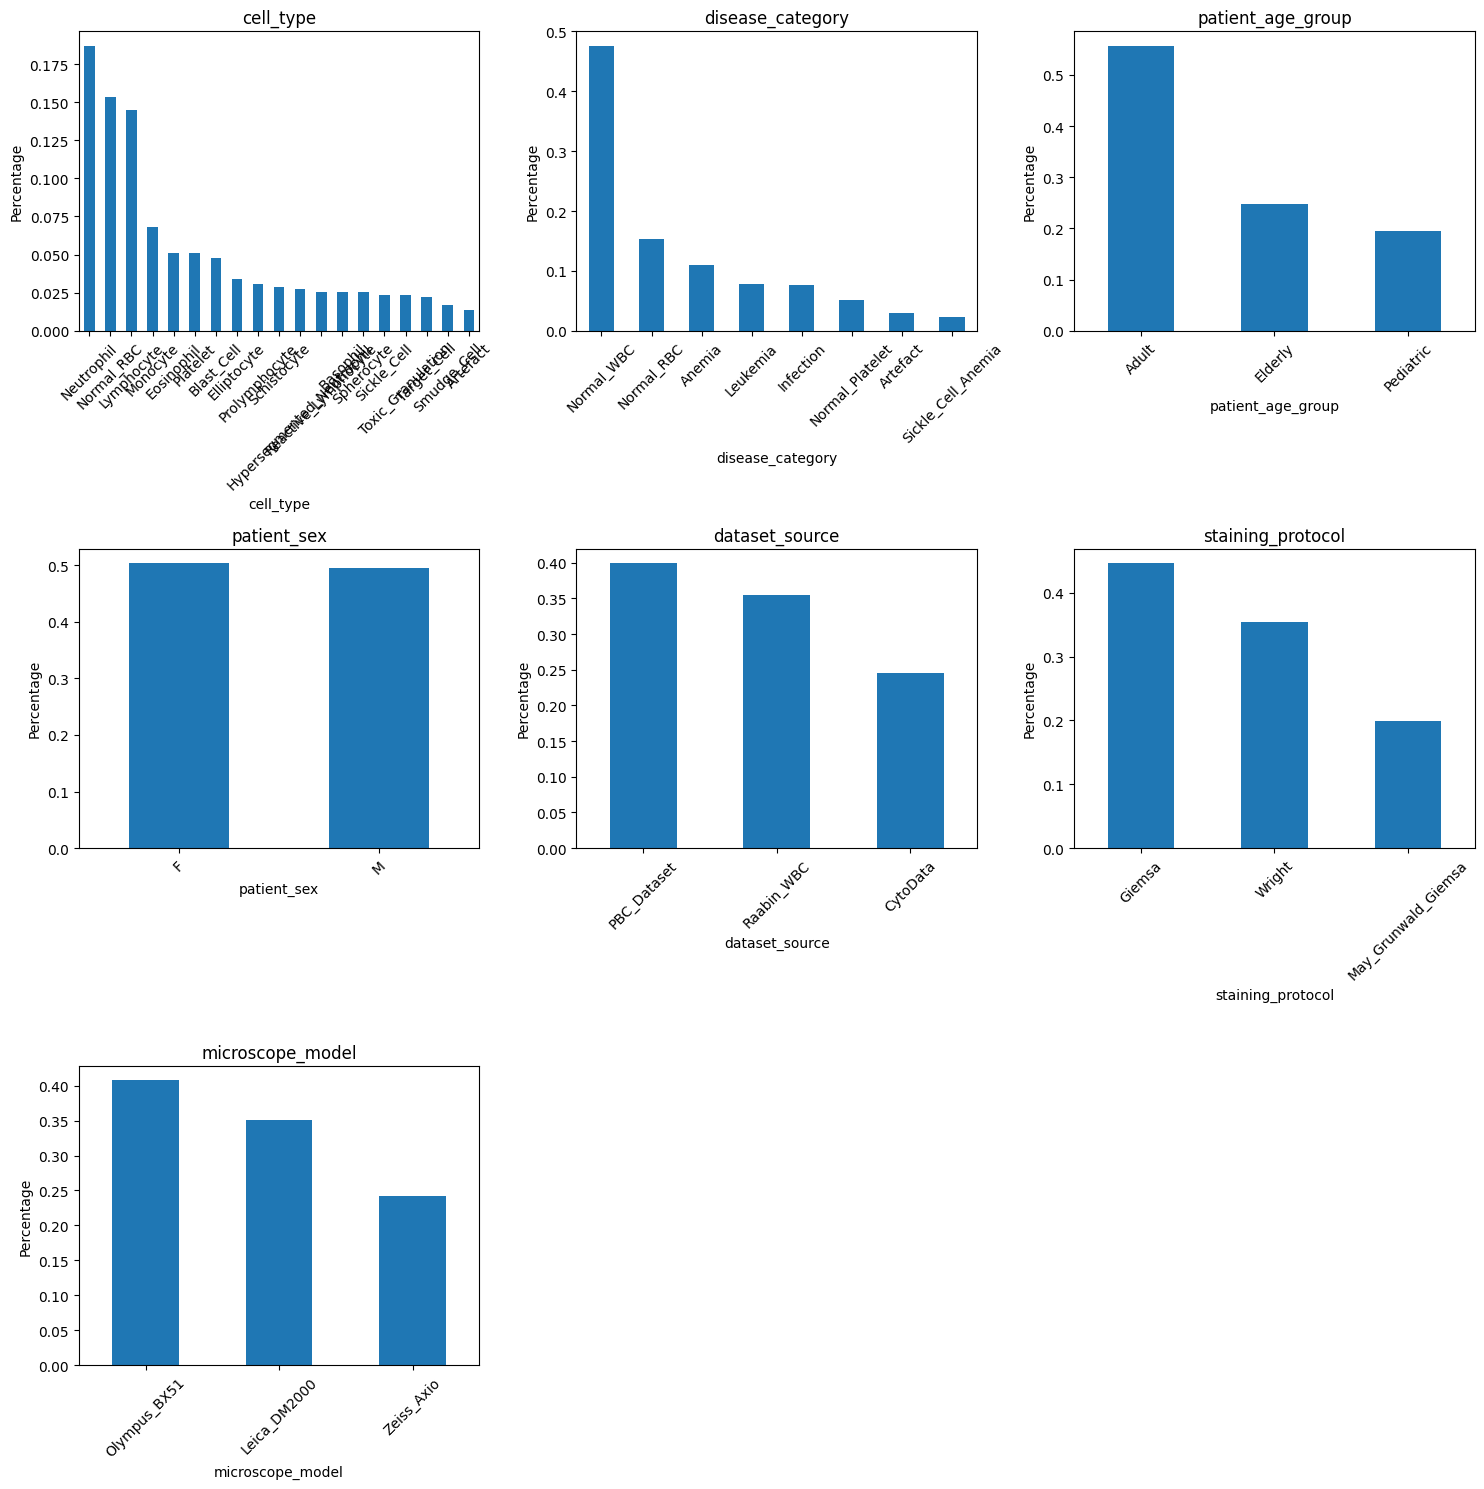

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

n_cols = 3
n_rows = (len(cat_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    df[col].value_counts(normalize=True).plot(kind='bar')
    plt.title(col)
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("categorical_distribution.png", dpi=300)
plt.show()

1. cell_type (Loại tế bào)
Đây là biến có nhiều giá trị nhất.

Chiếm ưu thế: Neutrophil, Normal_RBC, và Lymphocyte là ba loại tế bào phổ biến nhất, với Neutrophil dẫn đầu (gần 20%).

Nhóm hiếm: Các loại như Smudge_Cell hay Artefact chiếm tỷ lệ rất thấp (dưới 2.5%).

Nhận xét: Dữ liệu có sự mất cân bằng lớn giữa các loại tế bào, điều này cần lưu ý nếu bạn định dùng để huấn luyện mô hình phân loại.

2. disease_category (Danh mục bệnh lý)
Chiếm ưu thế tuyệt đối: Nhóm Normal_WBC chiếm gần 50% tổng số mẫu.

Các nhóm bệnh: Normal_RBC, Anemia, Leukemia, và Infection có tỷ lệ giảm dần (từ khoảng 15% xuống 8%).

Nhóm cực hiếm: Sickle_Cell_Anemia và Artefact có tỷ lệ thấp nhất.

Nhận xét: Tập dữ liệu tập trung chủ yếu vào các mẫu bình thường (Normal).

3. patient_age_group (Nhóm tuổi bệnh nhân)
Adult (Người trưởng thành): Chiếm đa số với hơn 50%.

Elderly (Người già): Chiếm khoảng 25%.

Pediatric (Trẻ em): Chiếm tỷ lệ thấp nhất (khoảng gần 20%).

4. patient_sex (Giới tính bệnh nhân)
Tỷ lệ: Biểu đồ cho thấy sự cân bằng khá tốt giữa Nữ (F) và Nam (M), mỗi bên chiếm xấp xỉ 50%.

Nhận xét: Biến này không bị lệch, đảm bảo tính đại diện cho cả hai giới tính.

5. dataset_source (Nguồn dữ liệu)
Dữ liệu được tổng hợp từ 3 nguồn chính:

PBC_Dataset: Chiếm tỷ lệ cao nhất (khoảng 40%).

Raabin_WBC: Đứng thứ hai (khoảng 35%).

CytoData: Chiếm ít nhất (khoảng 25%).

6. staining_protocol (Phương pháp nhuộm)
Giemsa: Là phương pháp phổ biến nhất (hơn 40%).

Wright: Đứng thứ hai (khoảng 35%).

May_Grunwald_Giemsa: Chiếm tỷ lệ thấp nhất (20%).

Nhận xét: Sự khác biệt về phương pháp nhuộm có thể ảnh hưởng đến màu sắc và độ tương phản của hình ảnh tế bào, cần chú ý khi xử lý tiền xử lý ảnh.

7. microscope_model (Mẫu kính hiển vi)
Olympus_BX51: Được sử dụng nhiều nhất (khoảng 40%).

Leica_DM2000: Chiếm khoảng 35%.

Zeiss_Axio: Chiếm tỷ lệ thấp nhất (khoảng 25%).

In [ ]:
def group_rare_categories(df, col, threshold=0.05):
    freq = df[col].value_counts(normalize=True)
    rare = freq[freq < threshold].index
    df[col] = df[col].replace(rare, 'Others')
    return df

for col in cat_cols:
    df = group_rare_categories(df, col)

## Tương quan với Target

Dựa trên các biểu đồ so sánh giữa các biến phân loại và biến mục tiêu anomaly_label (tỷ lệ bất thường - Anomaly Rate) để xác định mối tương quan giữa chúng.

In [45]:
cat_cols = [
    'cell_type',
    'disease_category',
    'patient_age_group',
    'patient_sex',
    'dataset_source',
    'staining_protocol',
    'microscope_model'
]

target = df['anomaly_label']

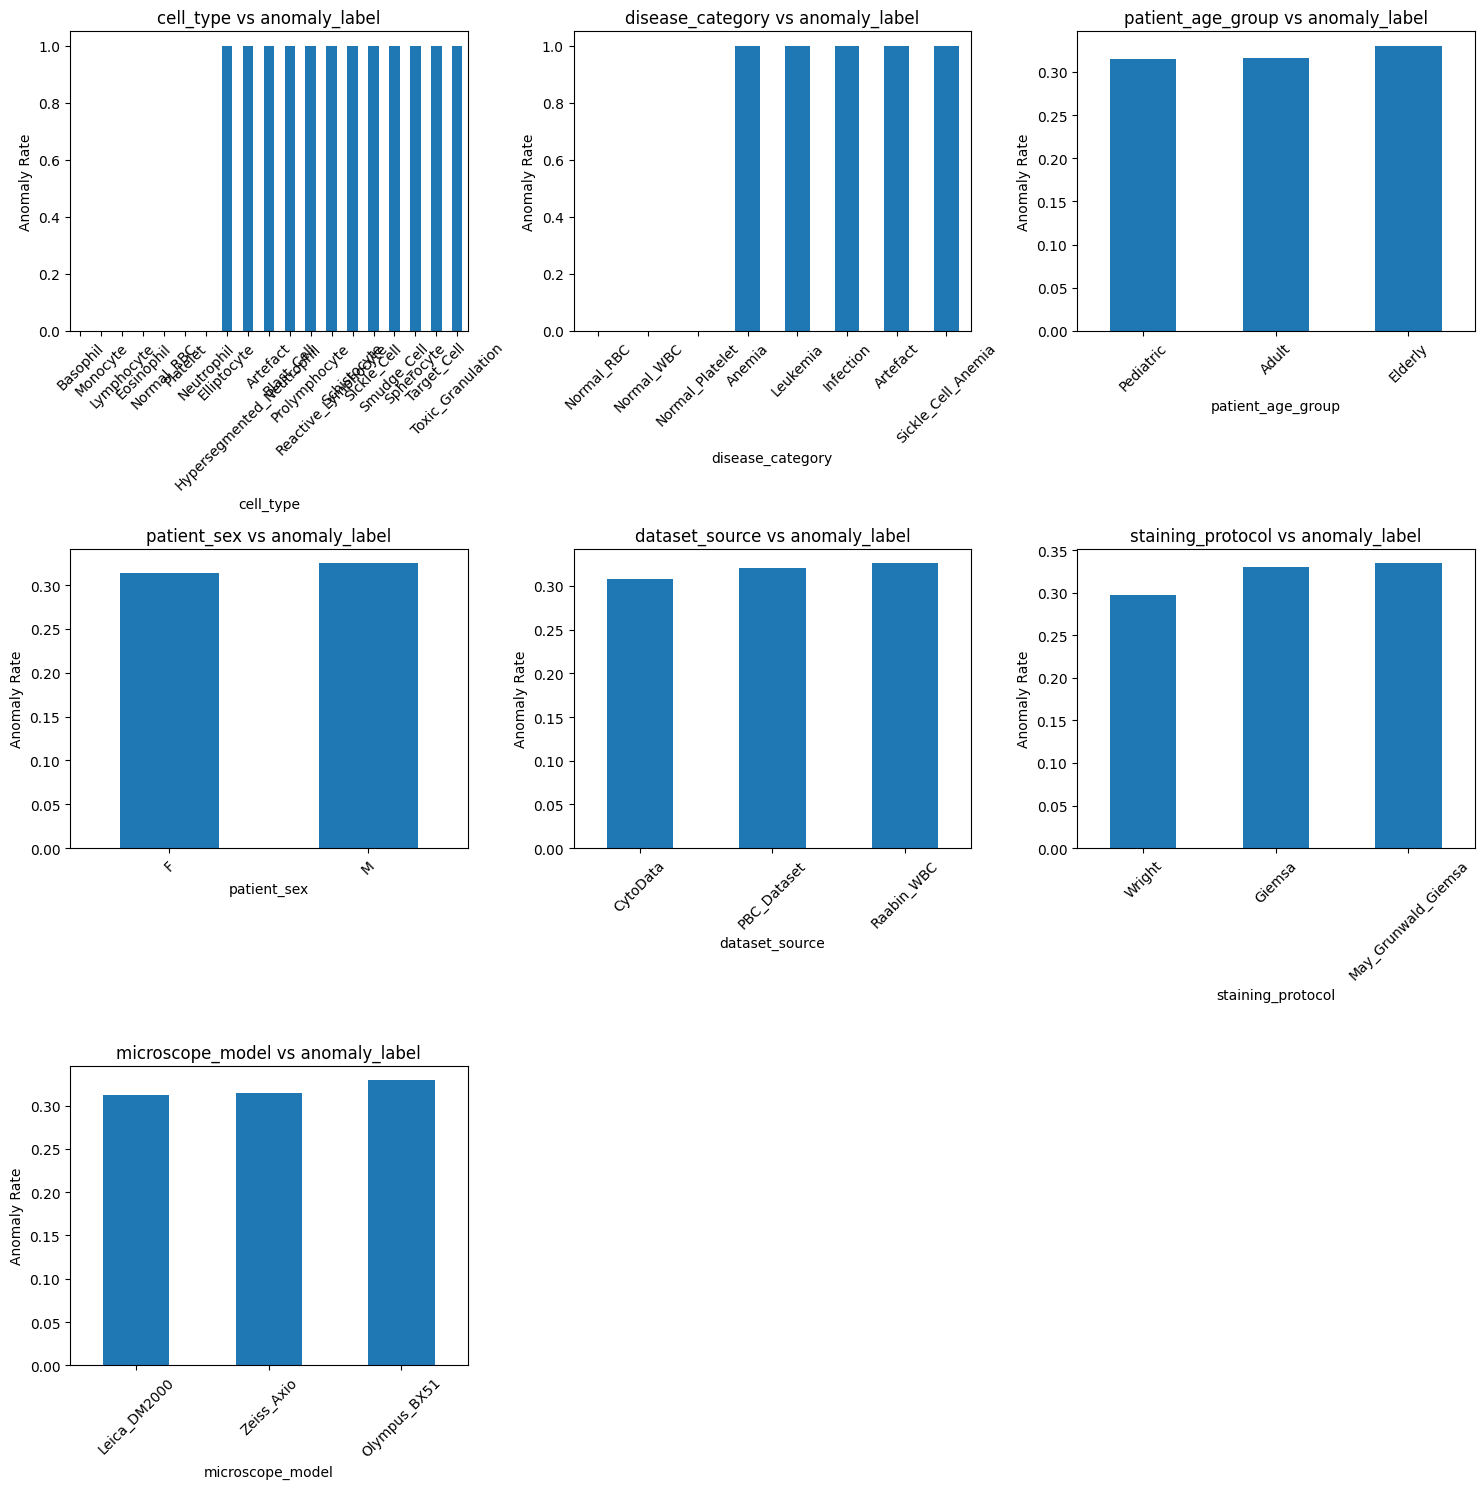

In [47]:
plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(cat_cols, 1):
    plt.subplot(n_rows, n_cols, i)

    # Fix: Use the column name 'anomaly_label' as a string instead of the target Series
    temp = df.groupby(col)['anomaly_label'].mean().sort_values()
    temp.plot(kind='bar')

    plt.title(f'{col} vs anomaly_label') # Update title for clarity
    plt.ylabel('Anomaly Rate')
    plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("categorical_vs_target.png", dpi=300)
plt.show()

1. cell_type vs anomaly_label

Đây là biến có sự phân hóa cực kỳ rõ rệt, gần như là một bộ lọc hoàn hảo:

Nhóm bình thường (Anomaly Rate = 0): Bao gồm Basophil, Monocyte, Lymphocyte, Eosinophil, Normal_RBC và Platelet. Các loại tế bào này hoàn toàn không có nhãn bất thường.

Nhóm bất thường (Anomaly Rate = 1.0): Toàn bộ các loại tế bào còn lại như Neutrophil, Elliptocyte, Artefact, Blast Cell... đều bị đánh nhãn bất thường 100%.

Kết luận: Loại tế bào là yếu tố quyết định trực tiếp đến việc một mẫu có bị coi là "anomaly" hay không trong tập dữ liệu này.

2. disease_category vs anomaly_label

Không bất thường: Normal_RBC và Normal_WBC có tỷ lệ bất thường bằng 0.

Chắc chắn bất thường: Các danh mục bệnh lý như Anemia, Leukemia, Infection, Artefact, Sickle_Cell_Anemia và cả Normal_Platelet đều có tỷ lệ bất thường là 1.0.

Lưu ý: Khá thú vị khi Normal_Platelet lại nằm trong nhóm có nhãn bất thường. Bạn nên kiểm tra lại định nghĩa "anomaly" trong dự án (có thể nó bao gồm bất kỳ trạng thái nào không phải là WBC/RBC bình thường).

3. Các biến đặc điểm bệnh nhân (Age group & Sex)

patient_age_group: Tỷ lệ bất thường khá đồng đều giữa các nhóm, dao động quanh mức 0.30 - 0.33. Nhóm Elderly (người già) có tỷ lệ nhỉnh hơn một chút so với Pediatric và Adult.

patient_sex: Không có sự khác biệt đáng kể giữa Nam (M) và Nữ (F), cả hai đều có tỷ lệ bất thường xấp xỉ 0.32.

Kết luận: Tuổi tác và giới tính không phải là những biến dự báo mạnh cho nhãn bất thường trong tập dữ liệu này.





4. Các biến kỹ thuật (Dataset Source, Staining, Microscope)

Ba biểu đồ này cho thấy các yếu tố kỹ thuật có ảnh hưởng rất ít đến tỷ lệ bất thường:

dataset_source: Các nguồn CytoData, PBC_Dataset, Raabin_WBC đều có tỷ lệ bất thường tương đương nhau (khoảng 0.31 - 0.33).

staining_protocol: Phương pháp nhuộm Wright có tỷ lệ thấp hơn một chút (~0.30) so với Giemsa và May_Grunwald_Giemsa (~0.33), nhưng mức chênh lệch không quá lớn.

microscope_model: Các mẫu kính hiển vi khác nhau cho kết quả tỷ lệ bất thường gần như đi ngang.

Biến quan trọng nhất: cell_type và disease_category. Đây là những biến mang tính chất "định nghĩa" cho nhãn bất thường. Nếu đưa hai biến này vào mô hình học máy, mô hình có thể đạt độ chính xác tuyệt đối (overfitting hoặc data leakage) vì nhãn mục tiêu được tạo ra trực tiếp từ chúng.

Biến nhiễu: Các yếu tố như giới tính, nguồn dữ liệu, phương pháp nhuộm và thiết bị không ảnh hưởng đến tỷ lệ bất thường. Điều này là tốt vì nó cho thấy nhãn bất thường được xác định dựa trên đặc điểm sinh học chứ không phải do sai lệch kỹ thuật thu thập ảnh.

## Chi-square

In [49]:
from scipy.stats import chi2_contingency

for col in cat_cols:
    contingency = pd.crosstab(df[col], df['anomaly_label'])
    chi2, p, dof, ex = chi2_contingency(contingency)

    print(f'{col}: p-value = {p}')

cell_type: p-value = 0.0
disease_category: p-value = 0.0
patient_age_group: p-value = 0.5896839899631177
patient_sex: p-value = 0.37649108823359123
dataset_source: p-value = 0.5202320307113071
staining_protocol: p-value = 0.026085393044911816
microscope_model: p-value = 0.4081973925828569


Trong thống kê, mức ý nghĩa phổ biến nhất là $\alpha = 0.05$:

Nếu p-value < 0.05: Biến đó có mối liên hệ có ý nghĩa thống kê với biến mục tiêu (bác bỏ giả thuyết độc lập).

Nếu p-value > 0.05: Biến đó độc lập với biến mục tiêu (không có sự khác biệt đáng kể).Dưới đây là phân tích chi tiết:

1. Nhóm có ảnh hưởng cực kỳ quan trọng ($p = 0.0$)

cell_type ($p = 0.0$)

disease_category ($p = 0.0$)

Phân tích: Đây là hai biến quan trọng nhất. Kết quả $p = 0.0$ (rất nhỏ) khẳng định rằng sự phân bổ của các nhãn bất thường phụ thuộc hoàn toàn vào loại tế bào và danh mục bệnh lý. Điều này khớp hoàn toàn với biểu đồ cột trước đó, nơi một số loại tế bào có tỷ lệ bất thường là 100% và một số là 0%.



2. Nhóm có ảnh hưởng nhẹ ($p = 0.026$)

staining_protocol ($p \approx 0.026$)

Phân tích: Vì $0.026 < 0.05$, biến này vẫn có ý nghĩa thống kê. Điều này có nghĩa là phương pháp nhuộm (Giemsa, Wright, May_Grunwald_Giemsa) có ảnh hưởng đến tỷ lệ phát hiện bất thường, dù mức độ ảnh hưởng không mạnh bằng loại tế bào. Có thể một số phương pháp nhuộm làm cho các đặc điểm bất thường rõ nét hơn, dẫn đến tỷ lệ gán nhãn khác nhau.


3. Nhóm không có ý nghĩa thống kê ($p > 0.05$)

patient_age_group ($p \approx 0.59$)

patient_sex ($p \approx 0.38$)

dataset_source ($p \approx 0.52$)

microscope_model ($p \approx 0.41$)

Phân tích: Tất cả các biến này đều có p-value lớn hơn 0.05 khá nhiều. Điều này khẳng định rằng: Giới tính, độ tuổi, nguồn dữ liệu hay mẫu kính hiển vi không làm thay đổi tỷ lệ xuất hiện bất thường một cách có hệ thống.Sự khác biệt nhỏ mà chúng ta thấy trên biểu đồ trước đó chỉ là do ngẫu nhiên trong quá trình lấy mẫu chứ không phải quy luật.

### Feature Selection Analysis

Các biến loại bỏ là các biến $p-value$ quá cao, giữ lại chỉ làm tăng chiều dữ liệu (Dimensionality) và gây nhiễu cho mô hình.

Danh sách các biến loại bỏ:

* cell_type: Data Leakage cực mạnh, vì rong y khoa, loại tế bào xác định tình trạng bệnh. Đưa vào model sẽ khiến AI chỉ "đọc chữ" chứ không "nhìn ảnh". Không dùng làm đầu vào. Chỉ dùng làm nhãn (target) nếu làm bài toán phân loại đa lớp.

* disease_category: Data Leakage tương tự cell_type, đây là kết quả sau cùng của chẩn đoán, không phải là thông tin đầu vào để dự báo.

* patient_sex / age: Độc lập thống kê ($p > 0.05$), không ảnh hưởng đến việc mẫu đó có bất thường hay không trong tập dữ liệu này.

* dataset_source: Loại bỏ vì không muốn model bị phụ thuộc vào việc dữ liệu lấy từ nguồn nào (bias nguồn thu thập). Có thể dùng để phân tách tập dữ liệu (GroupKFold) thay vì làm feature.

* microscope_model: Độc lập thống kê, model kính hiển vi không quyết định bản chất sinh học của tế bào.

Chỉ giữ lại một categorical feature:

staining_protocol: Có ý nghĩa thống kê ($p < 0.05$): Cách nhuộm ảnh hưởng trực tiếp đến màu sắc (RGB) của tế bào ( mean_g đã giữ lại ở phần numeric. )


Phương pháp xử lý: Mã hóa bằng One-Hot Encoding. Cần thực hiện Color Normalization cho ảnh để giảm sai biệt màu.



# Target feature

Kiểm tra imbalance

In [60]:
# Distribution của anomaly
df['anomaly_label'].value_counts(normalize=True)

,proportion
anomaly_label,
0,0.680272
1,0.319728


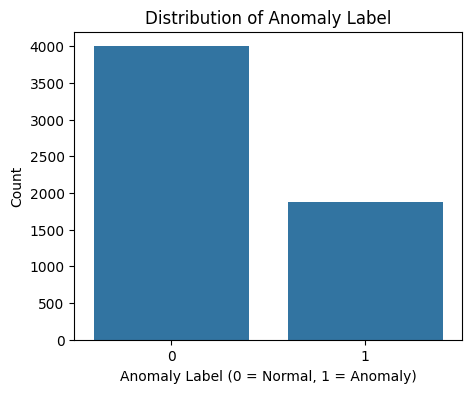

In [61]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))
sns.countplot(x='anomaly_label', data=df)

plt.title("Distribution of Anomaly Label")
plt.xlabel("Anomaly Label (0 = Normal, 1 = Anomaly)")
plt.ylabel("Count")

plt.show()

Dataset có tỷ lệ 68% normal và 32% anomaly, tức là không bị lệch quá nhiều giữa hai nhóm. Điều này giúp model học tốt cả hai class mà không cần phải cân bằng lại dữ liệu bằng các kỹ thuật như oversampling hay undersampling.

# Feature Selection

In [77]:

num_features = ['circularity', 'eccentricity', 'granularity_score', 'cell_area_px',
                'nucleus_area_pct', 'lobularity_score', 'mean_g']
cat_features = ['staining_protocol']
target = 'anomaly_label'

selected_cols = num_features + cat_features + [target]

df_clean = df[selected_cols].copy()


In [78]:
# Drop missing
df_clean = df_clean.dropna()

# Reset index cho gọn
df_clean = df_clean.reset_index(drop=True)

df_clean.to_csv("blood_cell_clean.csv", index=False)

Khi train model, sẽ dùng các cột đã chọn, và chạy PREPROCESSOR ở bước 2 (phương pháp xử lý chung), sau đó tùy vào tính chất model có thể xử lý thêm feature, test trên nhiều cách chia train test phù hợp, tunning tham số, ... sử dụng chung 1 metric đánh giá.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.metrics import recall_score, roc_auc_score, make_scorer

# 1. Thuật toán
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

# --- BƯỚC 1: CHUẨN BỊ DATA ---
num_features = ['circularity', 'eccentricity', 'granularity_score', 'cell_area_px',
                'nucleus_area_pct', 'lobularity_score', 'mean_g']
cat_features = ['staining_protocol']
target = 'anomaly_label'

X = df[num_features + cat_features]
y = df[target]

# Chia Train/Test cố định để cả nhóm dùng chung (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# --- BƯỚC 2: ĐỊNH NGHĨA PREPROCESSOR
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])